In [1]:

import numpy as np          
import h5py           
import matplotlib.pyplot as plt  
from sklearn.preprocessing import StandardScaler  
from sklearn.metrics import mean_squared_error    
from scipy import special    
from scipy.spatial.distance import cdist  
import warnings
warnings.filterwarnings('ignore') 

%matplotlib inline

print("All libraries imported successfully")

All libraries imported successfully


In [2]:
# Task 1.1
# Loading the weather data


data_file = 'data.h5'  


with h5py.File(data_file, 'r') as f:
    print(" Contents of the HDF5 file:")
    for key in f.keys():
        print(f"    - {key}: shape {f[key].shape}")
    
 # Loading training data 
    train = f['train'][:]                   
    train_timesteps = f['train_timesteps'][:]
    
# Loading test data
    test = f['test'][:]                   
    test_timesteps = f['test_timesteps'][:]   
    
# Loading station information
    station_names = [name.decode('utf-8') for name in f['station_names'][:]]
    station_lat = f['station_lat'][:]     
    station_lon = f['station_lon'][:]        
    station_altitude = f['station_altitude'][:]  
    
# Loading grid for predictions 
    grid = f['grid'][:]                    
    grid_altitude = f['grid_altitude'][:]   

print("\nData loaded successfully")
print(f"\n Data Overview:")
print(f"   Training data: {train.shape[0]} time steps × {train.shape[1]} stations")
print(f"   Test data: {test.shape[0]} time steps × {test.shape[1]} stations")
print(f"   Number of stations: {len(station_names)}")

# Grid information
print(f"\n Grid Information:")
print(f"   Grid shape: {grid.shape}")
print(f"   This means: {grid.shape[1]} × {grid.shape[2]} = {grid.shape[1] * grid.shape[2]} grid points")
print(f"    {grid.shape[1]} points in longitude direction")
print(f"    {grid.shape[2]} points in latitude direction")
print(f"    Total prediction points: {grid.shape[1] * grid.shape[2]}")

# Extract grid coordinates
grid_lon = grid[0, :, :]  
grid_lat = grid[1, :, :] 

print(f"\n   Grid longitude range: {grid_lon.min():.3f}° to {grid_lon.max():.3f}°")
print(f"   Grid latitude range: {grid_lat.min():.3f}° to {grid_lat.max():.3f}°")

 Contents of the HDF5 file:
    - grid: shape (2, 100, 100)
    - grid_altitude: shape (1, 100, 100)
    - station_altitude: shape (199,)
    - station_lat: shape (199,)
    - station_lon: shape (199,)
    - station_names: shape (199,)
    - test: shape (1439, 199)
    - test_timesteps: shape (1439,)
    - train: shape (2017, 199)
    - train_timesteps: shape (2017,)

Data loaded successfully

 Data Overview:
   Training data: 2017 time steps × 199 stations
   Test data: 1439 time steps × 199 stations
   Number of stations: 199

 Grid Information:
   Grid shape: (2, 100, 100)
   This means: 100 × 100 = 10000 grid points
    100 points in longitude direction
    100 points in latitude direction
    Total prediction points: 10000

   Grid longitude range: 9.000° to 17.500°
   Grid latitude range: 46.000° to 49.500°


In [3]:
# data exploration


print(" Task 1.1 Data Exploration")


# Temperature statistics
print("\n Temperature Statistics (all training data):")
print(f"   Minimum temperature: {np.min(train):.2f}°C")
print(f"   Maximum temperature: {np.max(train):.2f}°C")
print(f"   Average temperature: {np.mean(train):.2f}°C")
print(f"   Standard deviation: {np.std(train):.2f}°C")

# Station location statistics
print("\n Station Location:")
print(f"   Number of stations: {len(station_names)}")
print(f"   First 6 stations: {station_names[:6]}")
print(f"   Latitude range: {np.min(station_lat):.3f}° to {np.max(station_lat):.3f}°")
print(f"   Longitude range: {np.min(station_lon):.3f}° to {np.max(station_lon):.3f}°")
print(f"   Altitude range: {np.min(station_altitude):.0f}m to {np.max(station_altitude):.0f}m")

# Time information
print("\n Time Information:")
print(f"   Number of training timesteps: {len(train_timesteps)}")
print(f"   First timestamp: {train_timesteps[0]}")
print(f"   Last timestamp: {train_timesteps[-1]}")
print(f"   Number of test timesteps: {len(test_timesteps)}")
print(f"   First test timestamp: {test_timesteps[0]}")
print(f"   Last test timestamp: {test_timesteps[-1]}")

# Check for freezing temperatures
freezing_percentage = np.mean(train <= 0) * 100
print(f"\n Freezing Analysis:")
print(f"   Percentage of measurements ≤ 0°C: {freezing_percentage:.1f}%")

 Task 1.1 Data Exploration

 Temperature Statistics (all training data):
   Minimum temperature: -19.50°C
   Maximum temperature: 19.90°C
   Average temperature: 5.10°C
   Standard deviation: 5.33°C

 Station Location:
   Number of stations: 199
   First 6 stations: ['KAPFENBERG-FLUGFELD', 'GASCHURN', 'LITSCHAU', 'RAABS/THAYA', 'RETZ/WINDMUEHLE', 'FREISTADT']
   Latitude range: 46.444° to 48.955°
   Longitude range: 9.610° to 16.845°
   Altitude range: 116m to 3437m

 Time Information:
   Number of training timesteps: 2017
   First timestamp: b'2026-03-09T00:00+00:00'
   Last timestamp: b'2026-03-23T00:00+00:00'
   Number of test timesteps: 1439
   First test timestamp: b'2026-03-23T00:10+00:00'
   Last test timestamp: b'2026-04-01T23:50+00:00'

 Freezing Analysis:
   Percentage of measurements ≤ 0°C: 15.8%


Plotting station locations


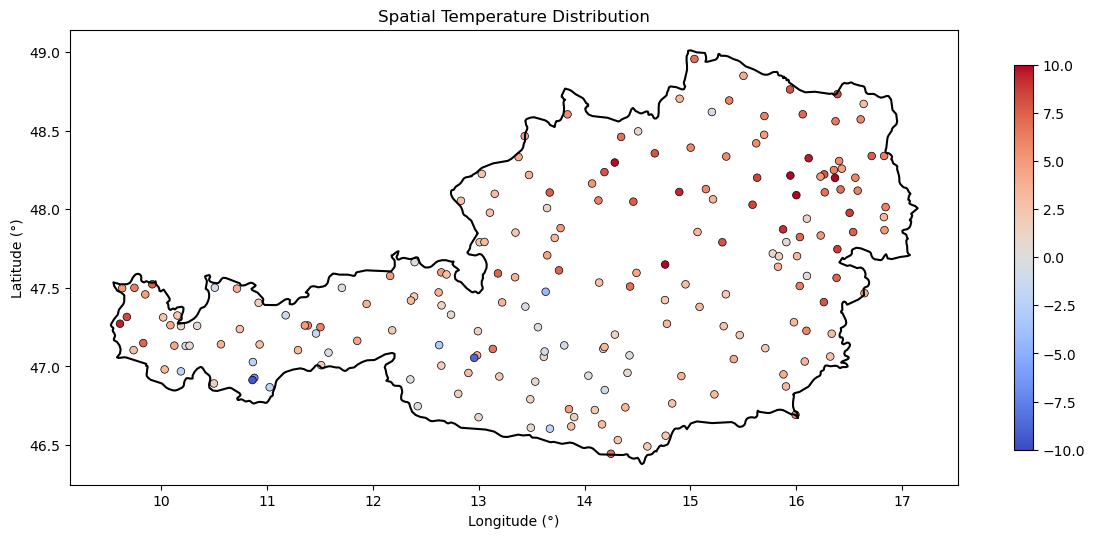

In [4]:
# Visualize station locations and temperature distributions

import geopandas as gpd
import pandas as pd
import matplotlib as mpl


# Copy the plot function from template
def plot(markers=None, predictions=None, title='', filename=None, vmin=None, vmax=None):
    """
    Plots weather prediction data.
    """
# Read Austria's border
    border = gpd.read_file('austria-detailed-boundary_854.geojson')
    border.set_crs(epsg=4326, inplace=True)

 # Data for markers (stations)
    if markers is not None:
        df_markers = pd.DataFrame({
            'longitude': markers[0],
            'latitude': markers[1],
            'temperature': markers[2]
        })
        gdf_markers = gpd.GeoDataFrame(df_markers, geometry=gpd.points_from_xy(df_markers.longitude, df_markers.latitude))
        gdf_markers.set_crs(epsg=4326, inplace=True)

 # Data for predictions
    if predictions is not None:
        df_predictions = pd.DataFrame({
            'longitude': predictions[0].ravel(),
            'latitude': predictions[1].ravel(),
            'temperature': predictions[2].ravel()
        })
        gdf_predictions = gpd.GeoDataFrame(df_predictions, geometry=gpd.points_from_xy(df_predictions.longitude, df_predictions.latitude))
        gdf_predictions.set_crs(epsg=4326, inplace=True)

 # Create plot
    fig, base = plt.subplots(1, 1, figsize=(12, 8))
    base.set_title(title)
    base.set_xlabel('Longitude (°)')
    base.set_ylabel('Latitude (°)')

 # Plot predictions (colored points)
    if predictions is not None:
        gdf_predictions_clipped = gdf_predictions.clip(mask=border)
        gdf_predictions_clipped.plot(ax=base, column='temperature', cmap='coolwarm', markersize=10, vmin=vmin, vmax=vmax)

# Show Austria border
    border.boundary.plot(ax=base, edgecolor='black', color=None, linewidth=1.5)

 # Plot markers (stations)
    if markers is not None:
        gdf_markers.plot(ax=base, column='temperature', cmap='coolwarm', markersize=30, 
                        edgecolor='black', linewidth=0.5, vmin=vmin, vmax=vmax)

 # Add colorbar
    if (markers is not None) or (predictions is not None):
        cmap = plt.cm.coolwarm
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
        sm.set_array([])
        fig.colorbar(sm, ax=base, location='right', pad=0.05, shrink=0.5)
        plt.tight_layout()

    if filename is None:
        plt.show()
    else:
        plt.savefig(filename, bbox_inches='tight')
        print(f" Plot saved as {filename}")

#  Ploting only station locations (no predictions yet)
print("Plotting station locations")

# Get temperatures for first timestep
station_temps = train[0, :]

# Call plot function with markers
plot(
    title='Spatial Temperature Distribution',
    markers=(station_lon, station_lat, station_temps),
    predictions=None,  
    filename=None,     
    vmin=-10, vmax=10
)


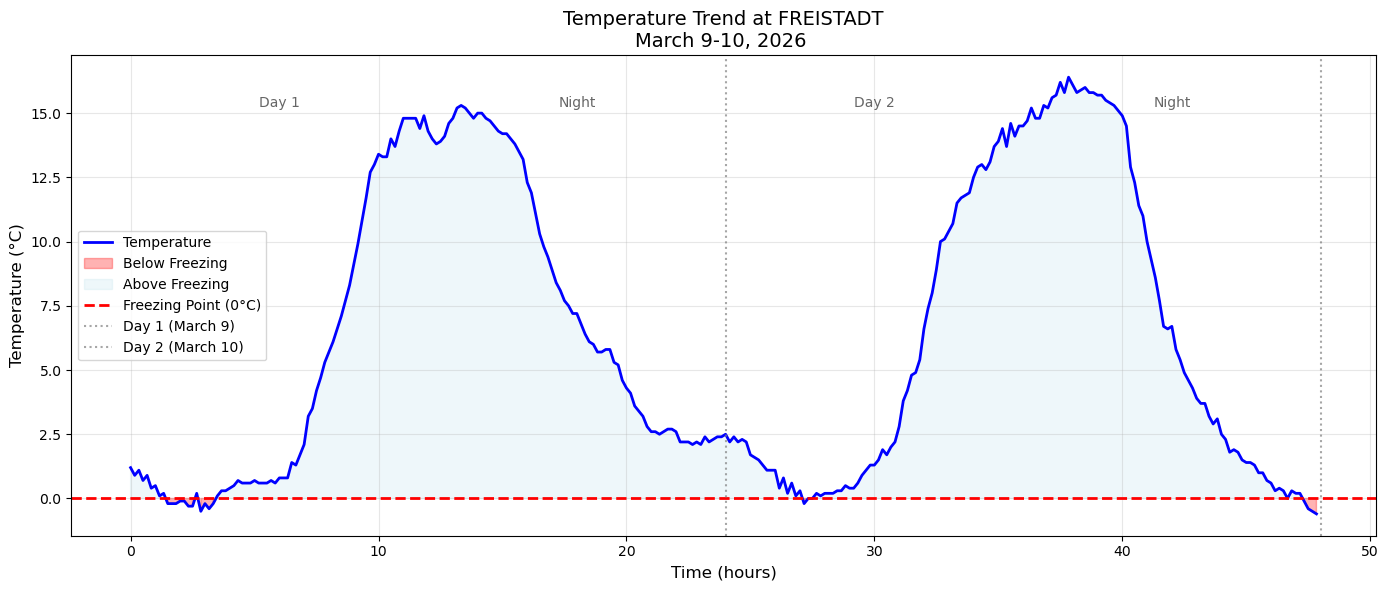


 Temperature Statistics for FREISTADT :
   Minimum temperature: -0.60°C
   Maximum temperature: 16.40°C
   Average temperature: 6.37°C
   Temperature range: 17.00°C

 Freezing Analysis:
   Hours below 0°C: 3.2 hours
   Percentage of time below freezing: 6.6%

 Daily Comparison:
   Day 1 average: 6.35°C
   Day 2 average: 6.39°C
   Difference: 0.04°C


In [5]:
#  Temperature trend at a specific location over 2 days

# Choose the fifth station
station_index = 5
station_name_selected = station_names[station_index]

# 2 days = 48 hours = 288 measurements (6 measurements per hour) (2 * 24 * 6)
num_measurements = 288
temperatures = train[:num_measurements, station_index]

# Create time axis (in hours)
time_hours = np.arange(num_measurements) / 6

# Create the plot
plt.figure(figsize=(14, 6))

# Plot temperature line
plt.plot(time_hours, temperatures, 'b-', linewidth=2, label='Temperature')

# Fill below freezing in red
plt.fill_between(time_hours, temperatures, 0,
                 where=(temperatures <= 0),
                 color='red', alpha=0.3, label='Below Freezing')

# Fill above freezing in light blue 
plt.fill_between(time_hours, temperatures, 0,
                 where=(temperatures > 0),
                 color='lightblue', alpha=0.2, label='Above Freezing')

plt.xlabel('Time (hours)', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.title(f'Temperature Trend at {station_name_selected}\nMarch 9-10, 2026 ', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Freezing Point (0°C)')

# Mark day boundaries
plt.axvline(x=24, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label='Day 1 (March 9)')
plt.axvline(x=48, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label='Day 2 (March 10)')

# Add annotations for day/night (approximate)
plt.text(6, plt.ylim()[1]-2, 'Day 1', ha='center', fontsize=10, alpha=0.6)
plt.text(18, plt.ylim()[1]-2, 'Night', ha='center', fontsize=10, alpha=0.6)
plt.text(30, plt.ylim()[1]-2, 'Day 2', ha='center', fontsize=10, alpha=0.6)
plt.text(42, plt.ylim()[1]-2, 'Night', ha='center', fontsize=10, alpha=0.6)

plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Print statistics
print(f"\n Temperature Statistics for {station_name_selected} :")
print(f"   Minimum temperature: {np.min(temperatures):.2f}°C")
print(f"   Maximum temperature: {np.max(temperatures):.2f}°C")
print(f"   Average temperature: {np.mean(temperatures):.2f}°C")
print(f"   Temperature range: {np.max(temperatures) - np.min(temperatures):.2f}°C")

# Freezing analysis
hours_below_freezing = np.sum(temperatures <= 0) / 6
percentage_below = (np.sum(temperatures <= 0) / len(temperatures)) * 100
print(f"\n Freezing Analysis:")
print(f"   Hours below 0°C: {hours_below_freezing:.1f} hours")
print(f"   Percentage of time below freezing: {percentage_below:.1f}%")

# Daily pattern analysis
day1_temps = temperatures[:144]  # First 24 hours
day2_temps = temperatures[144:288]  # Second 24 hours
print(f"\n Daily Comparison:")
print(f"   Day 1 average: {np.mean(day1_temps):.2f}°C")
print(f"   Day 2 average: {np.mean(day2_temps):.2f}°C")
print(f"   Difference: {np.mean(day2_temps) - np.mean(day1_temps):.2f}°C")


TASK 1.2: Feature Engineering 

 Extracting features from weather stations
   Longitude: 9.610° to 16.845°
   Latitude: 46.444° to 48.955°
   Altitude: 116m to 3437m

   Feature matrix shape: (199, 3)

 Normalizing features
   After normalization:
   - Mean: [ 0. -0. -0.]
   - Std: [1. 1. 1.]

  Preparing target variable
   Temperature range: -9.40°C to 10.50°C
   Normalized target - mean: -0.000, std: 1.000

 Grid Data
   Grid points: 10000 (100×100 grid)
   Longitude range: 9.000° to 17.500°
   Latitude range: 46.000° to 49.500°
   Altitude range: 41m to 3526m

   Grid feature matrix shape: (10000, 3)

 Summary:
   X_train: (199, 3) (199 stations × 3 features)
   y_train: (199,) (199 temperature values)
   X_grid: (10000, 3) (10000 grid points × 3 features)
Feature Visualization  


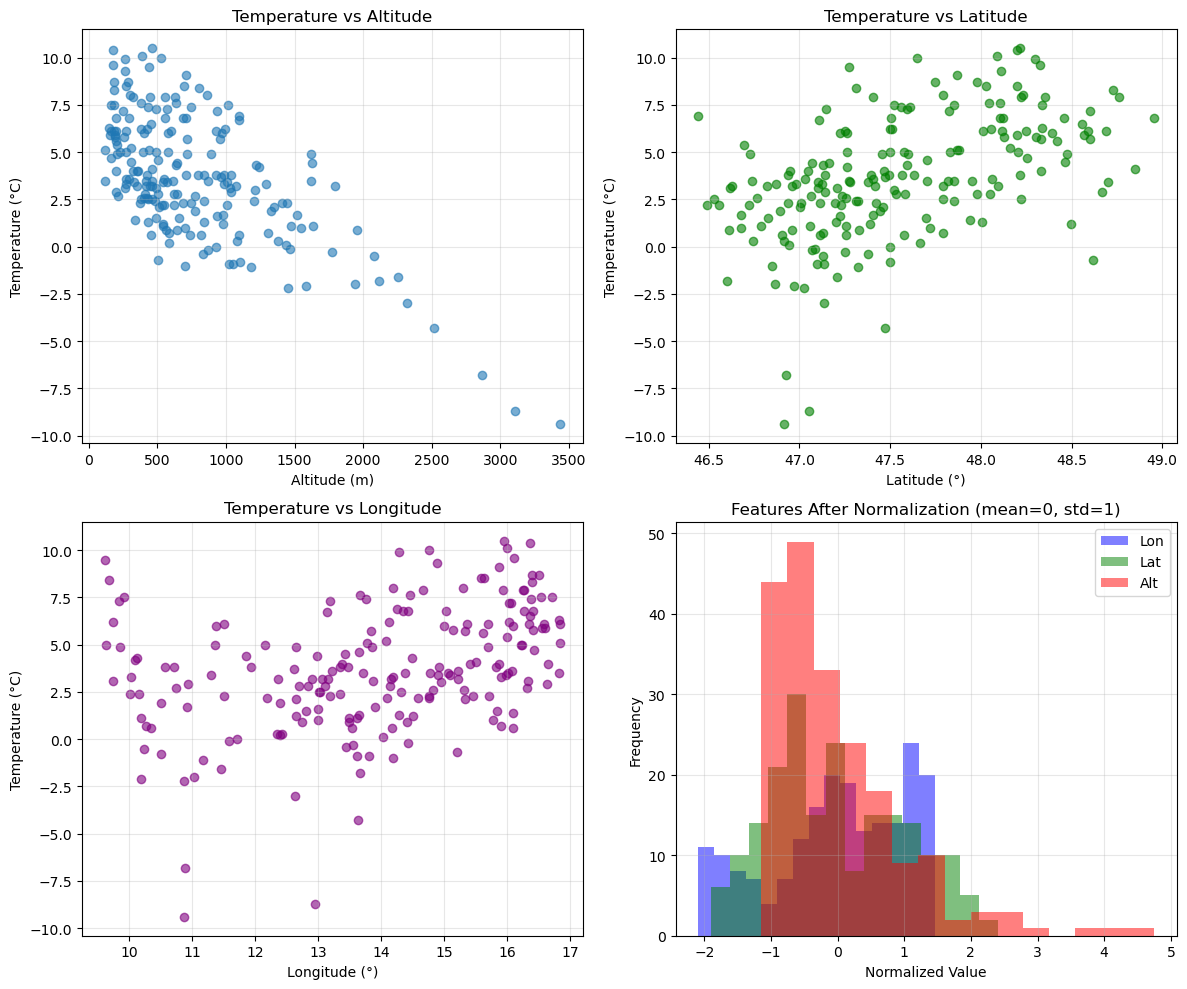


 Correlation with Temperature:
   Altitude: -0.662 (strongest)
   Latitude: 0.498
   Longitude: 0.372 (weakest)


In [6]:
#  Task 1.2: Feature Engineering


print("TASK 1.2: Feature Engineering ")


from sklearn.preprocessing import StandardScaler


print("\n Extracting features from weather stations")

# Feature 1 
longitude = station_lon
print(f"   Longitude: {longitude.min():.3f}° to {longitude.max():.3f}°")

# Feature 2 
latitude = station_lat
print(f"   Latitude: {latitude.min():.3f}° to {latitude.max():.3f}°")

# Feature 3
altitude = station_altitude
print(f"   Altitude: {altitude.min():.0f}m to {altitude.max():.0f}m")

# Combine into feature matrix (199 stations × 3 features)
X_raw = np.column_stack([longitude, latitude, altitude])
print(f"\n   Feature matrix shape: {X_raw.shape}")


print("\n Normalizing features")

scaler_X = StandardScaler()
X_normalized = scaler_X.fit_transform(X_raw)

print("   After normalization:")
print(f"   - Mean: {X_normalized.mean(axis=0).round(3)}")
print(f"   - Std: {X_normalized.std(axis=0).round(3)}")


print("\n  Preparing target variable")

# Use first timestep
y_temperature = train[0, :]
print(f"   Temperature range: {y_temperature.min():.2f}°C to {y_temperature.max():.2f}°C")

# Normalize target
scaler_y = StandardScaler()
y_normalized = scaler_y.fit_transform(y_temperature.reshape(-1, 1)).flatten()
print(f"   Normalized target - mean: {y_normalized.mean():.3f}, std: {y_normalized.std():.3f}")



print("\n Grid Data")

# Flatten the 2D grid to 1D
grid_lon_1d = grid[0, :, :].flatten()  # Longitudes: 100×100 = 10000 points
grid_lat_1d = grid[1, :, :].flatten()  # Latitudes: 100×100 = 10000 points
grid_alt_1d = grid_altitude.flatten()   # Altitudes: 100×100 = 10000 points

print(f"   Grid points: {len(grid_lon_1d)} (100×100 grid)")
print(f"   Longitude range: {grid_lon_1d.min():.3f}° to {grid_lon_1d.max():.3f}°")
print(f"   Latitude range: {grid_lat_1d.min():.3f}° to {grid_lat_1d.max():.3f}°")
print(f"   Altitude range: {grid_alt_1d.min():.0f}m to {grid_alt_1d.max():.0f}m")

# Create feature matrix for grid
X_grid_raw = np.column_stack([grid_lon_1d, grid_lat_1d, grid_alt_1d])
X_grid_normalized = scaler_X.transform(X_grid_raw)

print(f"\n   Grid feature matrix shape: {X_grid_normalized.shape}")



print("\n Summary:")
print(f"   X_train: {X_normalized.shape} (199 stations × 3 features)")
print(f"   y_train: {y_normalized.shape} (199 temperature values)")
print(f"   X_grid: {X_grid_normalized.shape} (10000 grid points × 3 features)")

# Save for later use
X_train = X_normalized
y_train = train[0, :]
X_grid = X_grid_normalized
grid_lon_plot = grid_lon_1d
grid_lat_plot = grid_lat_1d



# Feature Visualization 


print("Feature Visualization  ")


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Temperature vs Altitude 
axes[0,0].scatter(station_altitude, train[0, :], alpha=0.6)
axes[0,0].set_xlabel('Altitude (m)')
axes[0,0].set_ylabel('Temperature (°C)')
axes[0,0].set_title('Temperature vs Altitude')
axes[0,0].grid(True, alpha=0.3)

#  Temperature vs Latitude
axes[0,1].scatter(station_lat, train[0, :], alpha=0.6, color='green')
axes[0,1].set_xlabel('Latitude (°)')
axes[0,1].set_ylabel('Temperature (°C)')
axes[0,1].set_title('Temperature vs Latitude')
axes[0,1].grid(True, alpha=0.3)

#  Temperature vs Longitude
axes[1,0].scatter(station_lon, train[0, :], alpha=0.6, color='purple')
axes[1,0].set_xlabel('Longitude (°)')
axes[1,0].set_ylabel('Temperature (°C)')
axes[1,0].set_title('Temperature vs Longitude')
axes[1,0].grid(True, alpha=0.3)

#  Feature distributions after normalization
axes[1,1].hist(X_normalized[:, 0], bins=15, alpha=0.5, label='Lon', color='blue')
axes[1,1].hist(X_normalized[:, 1], bins=15, alpha=0.5, label='Lat', color='green')
axes[1,1].hist(X_normalized[:, 2], bins=15, alpha=0.5, label='Alt', color='red')
axes[1,1].set_xlabel('Normalized Value')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Features After Normalization (mean=0, std=1)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print(f"\n Correlation with Temperature:")
print(f"   Altitude: {np.corrcoef(station_altitude, train[0,:])[0,1]:.3f} (strongest)")
print(f"   Latitude: {np.corrcoef(station_lat, train[0,:])[0,1]:.3f}")
print(f"   Longitude: {np.corrcoef(station_lon, train[0,:])[0,1]:.3f} (weakest)")



In [7]:
# Task 2.1 Implement Bayesian Linear Regression

class BayesianLinearRegression:
    """
    Bayesian Linear Regression with Gaussian prior
    Implemented from scratch using only NumPy
    """
    
    def __init__(self, alpha=1.0, beta=25.0):
        """
        Parameters:
        alpha: Prior precision (regularization strength)
        beta: Noise precision (1/noise_variance)
        """
        self.alpha = alpha
        self.beta = beta
        self.w_mean = None
        self.w_cov = None
    
    def fit(self, X, y):
        """Train BLR model"""
     # Add bias term (column of 1's)
        n_samples = X.shape[0]
        X_with_bias = np.column_stack([np.ones(n_samples), X])
        n_features = X_with_bias.shape[1]
        
     # Compute X^T X
        XTX = X_with_bias.T @ X_with_bias
        
     # Posterior precision: S = αI + β X^T X
        I = np.eye(n_features)
        S = self.alpha * I + self.beta * XTX
        
     # Posterior covariance: Σ = S⁻¹
        self.w_cov = np.linalg.inv(S)
        
    # Posterior mean: μ = β Σ X^T y
        self.w_mean = self.beta * self.w_cov @ X_with_bias.T @ y
        
        return self
    
    def predict(self, X):
        """Make predictions with uncertainty"""
     # Add bias term
        n_samples = X.shape[0]
        X_with_bias = np.column_stack([np.ones(n_samples), X])
        
     # Predictive mean
        y_mean = X_with_bias @ self.w_mean
        
      # Predictive variance
        y_var = 1/self.beta + np.diag(X_with_bias @ self.w_cov @ X_with_bias.T)
        
        return y_mean, y_var

print(" BLR class defined")

 BLR class defined


In [8]:
#  Prepare training data


print("Preparing Taining data for BLR")

# X_normalized = normalized features (199 stations × 3 features)
# y_train = train[0, :] (temperatures at first timestep)

# Use the normalized features
X_train = X_normalized  
y_train = train[0, :]   

print(f"Training features shape: {X_train.shape}")
print(f"Training targets shape: {y_train.shape}")
print(f"Temperature range: {y_train.min():.2f}°C to {y_train.max():.2f}°C")

Preparing Taining data for BLR
Training features shape: (199, 3)
Training targets shape: (199,)
Temperature range: -9.40°C to 10.50°C


In [9]:
# Train BLR model


print("Training Bayesian Linear Regression")

blr = BayesianLinearRegression(alpha=1.0, beta=25.0)
blr.fit(X_train, y_train)

print(" BLR training complete")

# Print learned weights
print("\n Learned weights:")
print(f"   Bias: {blr.w_mean[0]:.3f}°C")
print(f"   Longitude: {blr.w_mean[1]:.3f}")
print(f"   Latitude: {blr.w_mean[2]:.3f}")
print(f"   Altitude: {blr.w_mean[3]:.3f}")

Training Bayesian Linear Regression
 BLR training complete

 Learned weights:
   Bias: 3.665°C
   Longitude: -0.120
   Latitude: 0.858
   Altitude: -1.850


In [10]:
# Grid Prediction


print("Prediction on grid")



# Grid shape: (2, 100, 100)
grid_lon_flat = grid[0, :, :].flatten()
grid_lat_flat = grid[1, :, :].flatten()
grid_alt_flat = np.squeeze(grid_altitude).flatten()

X_grid_raw = np.column_stack([grid_lon_flat, grid_lat_flat, grid_alt_flat])

print(f"\nGrid raw features shape: {X_grid_raw.shape}")
print(f"Grid points: {X_grid_raw.shape[0]}")


#  Normalize grid using same scaler


X_grid = scaler_X.transform(X_grid_raw)

print(f"\nGrid normalized features shape: {X_grid.shape}")
print(f"Normalized range: {X_grid.min():.2f} to {X_grid.max():.2f}")


# Make predictions

predictions, uncertainties = blr.predict(X_grid)

print(f"\n Prediction Results:")
print(f"   Predictions shape: {predictions.shape}")
print(f"   Prediction range: {predictions.min():.2f}°C to {predictions.max():.2f}°C")
print(f"   Mean prediction: {predictions.mean():.2f}°C")

print(f"\n Uncertainty Results:")
print(f"   Uncertainty range: {np.sqrt(uncertainties.min()):.4f}°C to {np.sqrt(uncertainties.max()):.4f}°C")
print(f"   Mean uncertainty: {np.sqrt(uncertainties.mean()):.4f}°C")


#  Reshape for visualization


predictions_map = predictions.reshape(100, 100)
uncertainty_map = uncertainties.reshape(100, 100)

print(f"\n Reshaped maps:")
print(f"   Predictions map: {predictions_map.shape}")
print(f"   Uncertainty map: {uncertainty_map.shape}")



Prediction on grid

Grid raw features shape: (10000, 3)
Grid points: 10000

Grid normalized features shape: (10000, 3)
Normalized range: -2.67 to 4.90

 Prediction Results:
   Predictions shape: (10000,)
   Prediction range: -6.78°C to 8.58°C
   Mean prediction: 3.92°C

 Uncertainty Results:
   Uncertainty range: 0.2005°C to 0.2151°C
   Mean uncertainty: 0.2041°C

 Reshaped maps:
   Predictions map: (100, 100)
   Uncertainty map: (100, 100)


Visualizing BLR predictions


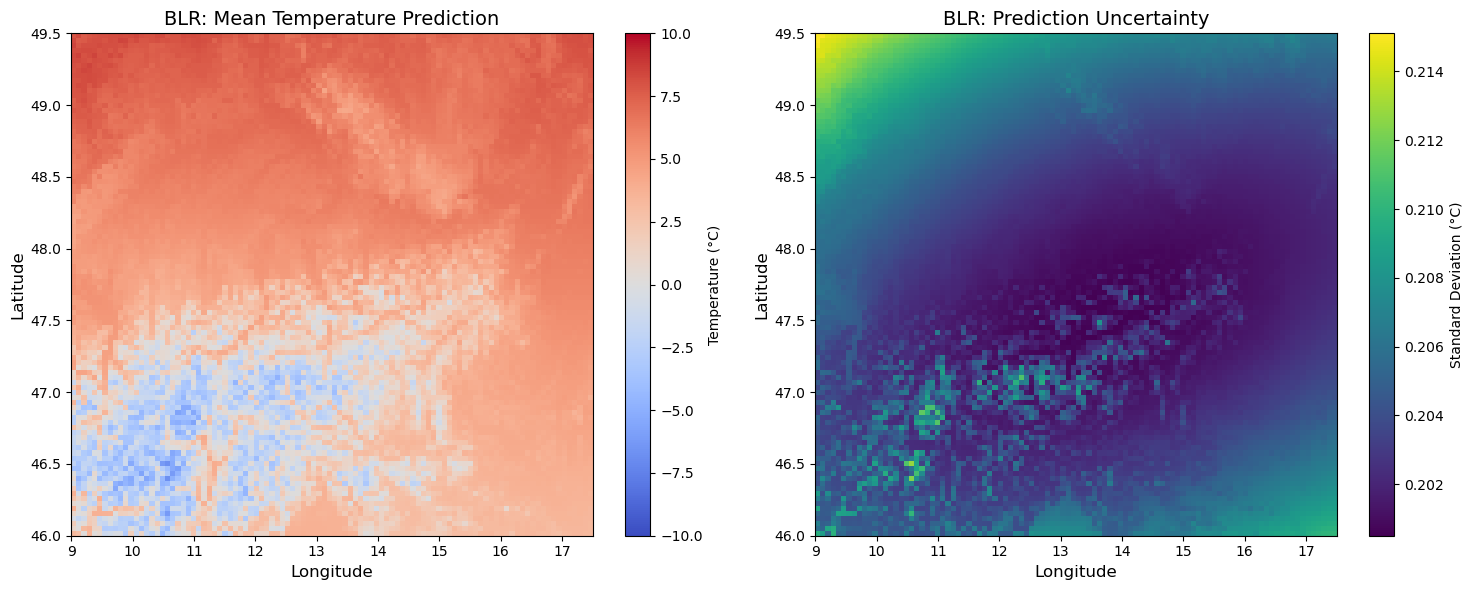

In [11]:
# Visualize BLR predictions


print("Visualizing BLR predictions")


fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Mean temperature prediction
im1 = axes[0].imshow(predictions_map, 
                     extent=[grid_lon_flat.min(), grid_lon_flat.max(),
                            grid_lat_flat.min(), grid_lat_flat.max()],
                     origin='lower', cmap='coolwarm', aspect='auto',
                     vmin=-10, vmax=10)
axes[0].set_title('BLR: Mean Temperature Prediction', fontsize=14)
axes[0].set_xlabel('Longitude', fontsize=12)
axes[0].set_ylabel('Latitude', fontsize=12)
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Temperature (°C)', fontsize=10)

# Plot 2: Prediction uncertainty
im2 = axes[1].imshow(np.sqrt(uncertainty_map), 
                     extent=[grid_lon_flat.min(), grid_lon_flat.max(),
                            grid_lat_flat.min(), grid_lat_flat.max()],
                     origin='lower', cmap='viridis', aspect='auto')
axes[1].set_title('BLR: Prediction Uncertainty', fontsize=14)
axes[1].set_xlabel('Longitude', fontsize=12)
axes[1].set_ylabel('Latitude', fontsize=12)
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('Standard Deviation (°C)', fontsize=10)

plt.tight_layout()
plt.show()





Interpretation:
    Left map: Predicted temperature across Austria
    Blue colors = colder areas (mountains, higher altitude)
    Red colors = warmer areas (lowlands, eastern Austria)
    Right map: Uncertainty is nearly uniform (~0.20°C), reflecting that BLR is a global linear model and does not adapt locally.

In [12]:
# Task 2.2: Implement Gaussian Process

from scipy.spatial.distance import cdist

class RBFKernel:
    """
    Radial Basis Function (RBF) Kernel
    Also known as Squared Exponential Kernels
    
    Formula: k(x,x') = σ_f² * exp(-||x-x'||² / (2ℓ²))
    
    Parameters:
    - length_scale (ℓ): How far apart points can be and still influence each other
    - sigma_f (σ_f): Controls the magnitude of variations
    """
    def __init__(self, length_scale=0.5, sigma_f=1.0):
        self.length_scale = length_scale
        self.sigma_f = sigma_f
    
    def __call__(self, X1, X2):
        """
        Compute kernel matrix between X1 and X2
        
        Returns: Matrix K where K[i,j] = k(X1[i], X2[j])
        """
        # Compute squared Euclidean distances
        sq_dist = cdist(X1, X2, 'sqeuclidean')
        
        # Apply RBF formula
        K = self.sigma_f**2 * np.exp(-0.5 * sq_dist / self.length_scale**2)
        return K


class GaussianProcess:
    """
    Gaussian Process Regression
    
    KEY IDEA: Instead of modeling weights (like BLR), 
    GP models the function directly as a distribution over functions.
    
    f(x) ~ GP(0, k(x,x'))
    y = f(x) + ε, where ε ~ N(0, σ_n²)
    
    PREDICTIVE DISTRIBUTION:
    - Mean: μ* = K(x*, X) [K(X,X) + σ_n²I]⁻¹ y
    - Variance: σ*² = k(x*,x*) - K(x*,X) [K(X,X) + σ_n²I]⁻¹ K(X,x*) + σ_n²
    """
    
    def __init__(self, kernel, noise_variance=0.5):
        """
        Parameters:
        - kernel: The kernel function (e.g., RBFKernel)
        - noise_variance: σ_n², measurement noise
        """
        self.kernel = kernel
        self.noise_variance = noise_variance
        self.X_train = None
        self.y_train = None
        self.K_inv = None  # Precomputed inverse for faster predictions
    
    def fit(self, X, y):
        """
        Train the GP by precomputing the inverse kernel matrix
        
        X: Training features (199 stations × 3 features)
        y: Training targets (199 temperatures)
        """
        self.X_train = X
        self.y_train = y
        
        # Compute kernel matrix K(X,X)
        K = self.kernel(X, X)
        
        # Add noise to diagonal (for numerical stability and measurement noise)
        K += self.noise_variance * np.eye(len(X))
        
        # Precompute inverse (for faster predictions)
        self.K_inv = np.linalg.inv(K)
        
        print(f"   Kernel matrix shape: {K.shape}")
        print(f"   Condition number: {np.linalg.cond(K):.2e}")
        
        return self
    
    def predict(self, X):
     # Compute kernel between training and test
     K_s = self.kernel(self.X_train, X)
     
     # Predictive mean
     y_mean = K_s.T @ self.K_inv @ self.y_train
    
     # Efficient variance (no huge matrix)
     k_ss_diag = np.full(X.shape[0], self.kernel.sigma_f**2)
     y_var = k_ss_diag - np.sum(K_s * (self.K_inv @ K_s), axis=0)
    
     # Numerical stability
     y_var = np.maximum(y_var, 1e-10)
    
     # Add noise
     y_var += self.noise_variance
    
     return y_mean, y_var
        

print("RBF Kernel and Gaussian Process classes defined")

RBF Kernel and Gaussian Process classes defined


TASK 2.2: Gaussian Process Regression

 Training Data:
   Features shape: (199, 3)
   Targets shape: (199,)
   Temperature range: -9.40°C to 10.50°C

Two Bandwidth Choices :
   Bandwidth 1 (small, local): l = 0.3
   Bandwidth 2 (large, smooth): l = 1.5
 
 GP MODEL 1: Small Length Scale (l = 0.3)
   Kernel matrix shape: (199, 199)
   Condition number: 5.24e+02

 GP Model 1 Results:
   Temperature range: -7.31°C to 11.61°C
   Mean temperature: 1.59°C
   Mean uncertainty: 4.2401°C
   Uncertainty range: 0.7893 to 5.0498°C
 
GP MODEL 2: Large Length Scale (l = 1.5)
   Kernel matrix shape: (199, 199)
   Condition number: 4.43e+03

 GP Model 2 Results:
   Temperature range: -9.15°C to 10.87°C
   Mean temperature: 2.62°C
   Mean uncertainty: 1.7199°C
   Uncertainty range: 0.7237 to 4.7594°C
Reshaping for Visualization

  GP Model 1 predictions map: (100, 100)
   GP Model 1 uncertainty map: (100, 100)
   GP Model 2 predictions map: (100, 100)
   GP Model 2 uncertainty map: (100, 100)
 
 Visuali

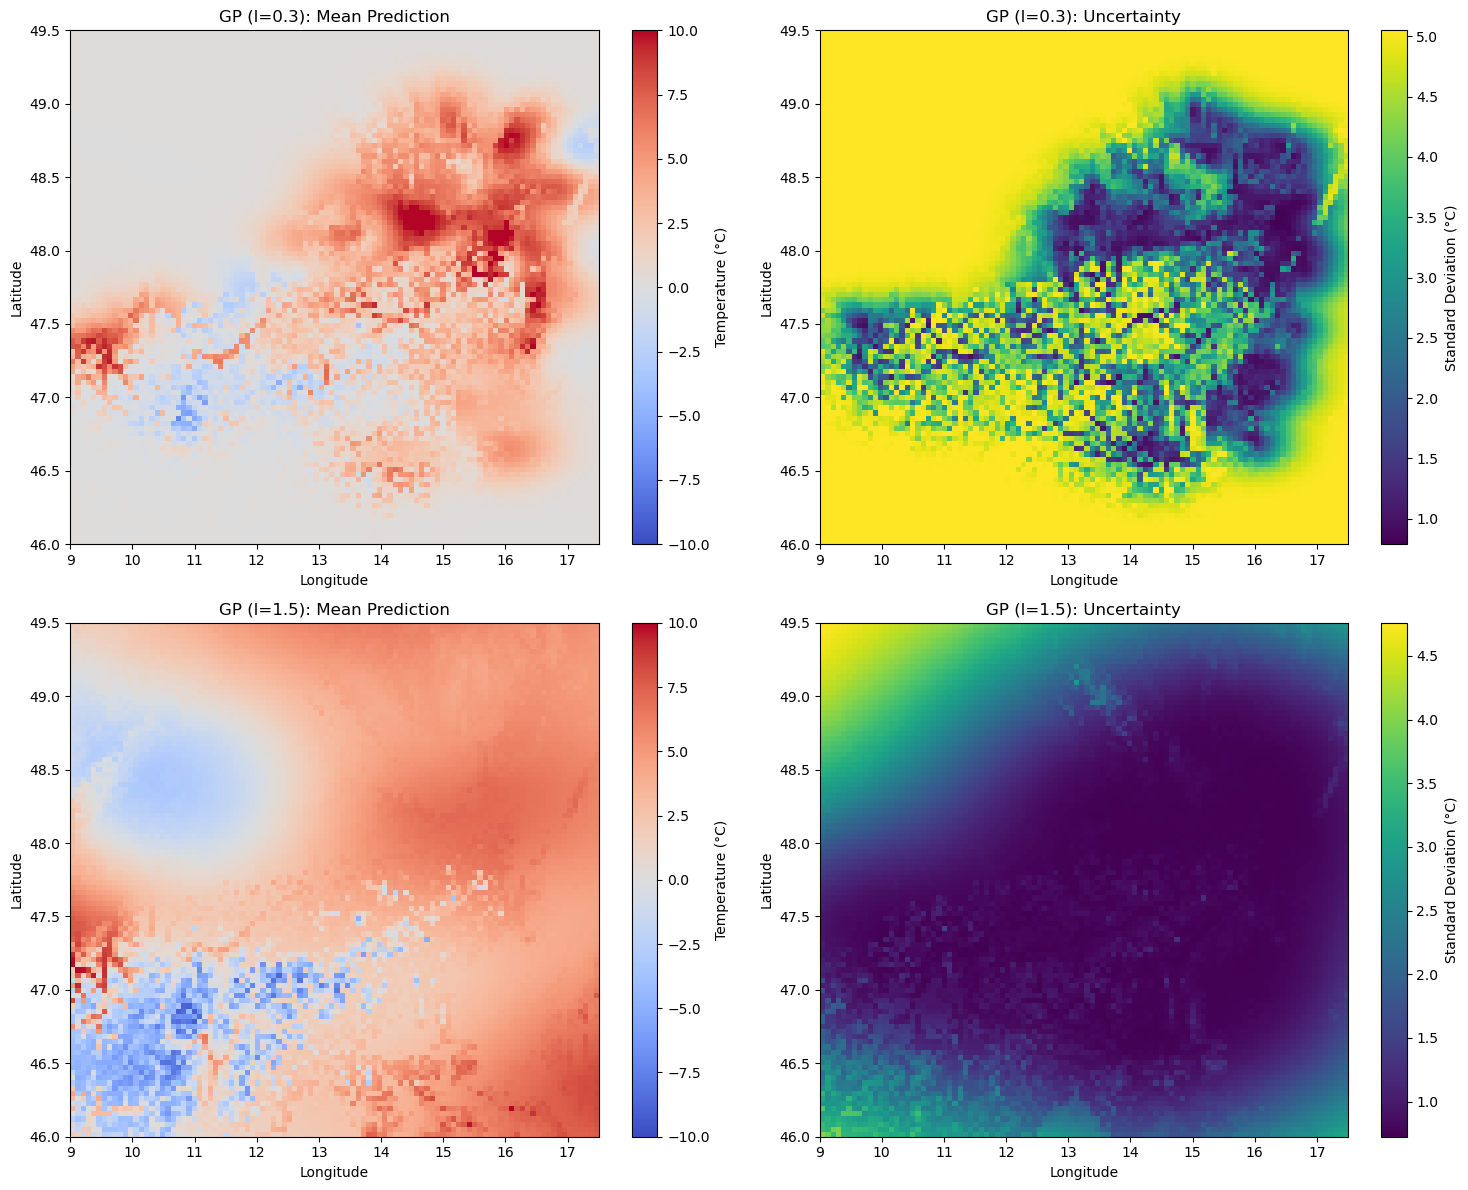

In [13]:
#  Train Gaussian Process on same data as BLR


print("TASK 2.2: Gaussian Process Regression")

# Use the SAME normalized training data as BLR
# X_train and y_train are already defined from BLR
print(f"\n Training Data:")
print(f"   Features shape: {X_train.shape}")
print(f"   Targets shape: {y_train.shape}")
print(f"   Temperature range: {y_train.min():.2f}°C to {y_train.max():.2f}°C")

# define two bandwidths (length scales)


length_scale_1 = 0.3   # Small length scale 
length_scale_2 = 1.5   # Large length scale 

print(f"\nTwo Bandwidth Choices :")
print(f"   Bandwidth 1 (small, local): l = {length_scale_1}")
print(f"   Bandwidth 2 (large, smooth): l = {length_scale_2}")


# Train GP model 1


print(f" \n GP MODEL 1: Small Length Scale (l = {length_scale_1})")


kernel1 = RBFKernel(length_scale=length_scale_1, sigma_f=5.0)
gp1 = GaussianProcess(kernel1, noise_variance=0.5)
gp1.fit(X_train, y_train)

# Predict with Model 1
gp1_mean, gp1_var = gp1.predict(X_grid)
gp1_predictions_map = gp1_mean.reshape(100, 100)
gp1_uncertainty_map = gp1_var.reshape(100, 100)

print(f"\n GP Model 1 Results:")
print(f"   Temperature range: {gp1_mean.min():.2f}°C to {gp1_mean.max():.2f}°C")
print(f"   Mean temperature: {gp1_mean.mean():.2f}°C")
print(f"   Mean uncertainty: {np.sqrt(gp1_var.mean()):.4f}°C")
print(f"   Uncertainty range: {np.sqrt(gp1_var.min()):.4f} to {np.sqrt(gp1_var.max()):.4f}°C")

# Train GP Model 2

print(f" \nGP MODEL 2: Large Length Scale (l = {length_scale_2})")


kernel2 = RBFKernel(length_scale=length_scale_2, sigma_f=5.0)
gp2 = GaussianProcess(kernel2, noise_variance=0.5)
gp2.fit(X_train, y_train)

# Predict with Model 2
gp2_mean, gp2_var = gp2.predict(X_grid)
gp2_predictions_map = gp2_mean.reshape(100, 100)
gp2_uncertainty_map = gp2_var.reshape(100, 100)

print(f"\n GP Model 2 Results:")
print(f"   Temperature range: {gp2_mean.min():.2f}°C to {gp2_mean.max():.2f}°C")
print(f"   Mean temperature: {gp2_mean.mean():.2f}°C")
print(f"   Mean uncertainty: {np.sqrt(gp2_var.mean()):.4f}°C")
print(f"   Uncertainty range: {np.sqrt(gp2_var.min()):.4f} to {np.sqrt(gp2_var.max()):.4f}°C")

# Reshape for Visualization


print("Reshaping for Visualization")


print(f"\n  GP Model 1 predictions map: {gp1_predictions_map.shape}")
print(f"   GP Model 1 uncertainty map: {gp1_uncertainty_map.shape}")
print(f"   GP Model 2 predictions map: {gp2_predictions_map.shape}")
print(f"   GP Model 2 uncertainty map: {gp2_uncertainty_map.shape}")

# Visualizing both GP models


print(" \n Visualizing Both GP Models")


fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# GP Model 1 - Mean Prediction



im1 = axes[0,0].imshow(gp1_predictions_map, 
                       extent=[grid_lon_flat.min(), grid_lon_flat.max(),
                              grid_lat_flat.min(), grid_lat_flat.max()],
                       origin='lower', cmap='coolwarm', aspect='auto',
                       vmin=-10, vmax=10)
axes[0,0].set_title(f'GP (l={length_scale_1}): Mean Prediction', fontsize=12)
axes[0,0].set_xlabel('Longitude')
axes[0,0].set_ylabel('Latitude')
plt.colorbar(im1, ax=axes[0,0], label='Temperature (°C)')

# GP Model 1 - Uncertainty
im2 = axes[0,1].imshow(np.sqrt(gp1_uncertainty_map), 
                       extent=[grid_lon_flat.min(), grid_lon_flat.max(),
                              grid_lat_flat.min(), grid_lat_flat.max()],
                       origin='lower', cmap='viridis', aspect='auto')
axes[0,1].set_title(f'GP (l={length_scale_1}): Uncertainty', fontsize=12)
axes[0,1].set_xlabel('Longitude')
axes[0,1].set_ylabel('Latitude')
plt.colorbar(im2, ax=axes[0,1], label='Standard Deviation (°C)')

# GP Model 2 - Mean Prediction
im3 = axes[1,0].imshow(gp2_predictions_map, 
                       extent=[grid_lon_flat.min(), grid_lon_flat.max(),
                              grid_lat_flat.min(), grid_lat_flat.max()],
                       origin='lower', cmap='coolwarm', aspect='auto',
                       vmin=-10, vmax=10)
axes[1,0].set_title(f'GP (l={length_scale_2}): Mean Prediction', fontsize=12)
axes[1,0].set_xlabel('Longitude')
axes[1,0].set_ylabel('Latitude')
plt.colorbar(im3, ax=axes[1,0], label='Temperature (°C)')

# GP Model 2 - Uncertainty
im4 = axes[1,1].imshow(np.sqrt(gp2_uncertainty_map), 
                       extent=[grid_lon_flat.min(), grid_lon_flat.max(),
                              grid_lat_flat.min(), grid_lat_flat.max()],
                       origin='lower', cmap='viridis', aspect='auto')
axes[1,1].set_title(f'GP (l={length_scale_2}): Uncertainty', fontsize=12)
axes[1,1].set_xlabel('Longitude')
axes[1,1].set_ylabel('Latitude')
plt.colorbar(im4, ax=axes[1,1], label='Standard Deviation (°C)')

plt.tight_layout()
plt.show()



Interpretation of GP Results

Mean Prediction

ℓ = 0.3 (small bandwidth):
Produces highly local and irregular predictions. The temperature map appears noisy and fragmented, capturing fine details but lacking smooth spatial structure.
ℓ = 1.5 (large bandwidth):
Produces smooth and continuous predictions. Captures realistic spatial patterns such as colder mountainous regions and warmer lowlands.

Uncertainty

ℓ = 0.3 (small bandwidth):
Very high uncertainty, especially far from stations. The model relies heavily on nearby data and does not generalize well.
ℓ = 1.5 (large bandwidth):
Lower and smoother uncertainty. Shows clear spatial behavior — low near stations and higher in remote regions, which is more realistic.

BLR vs Two GP Models


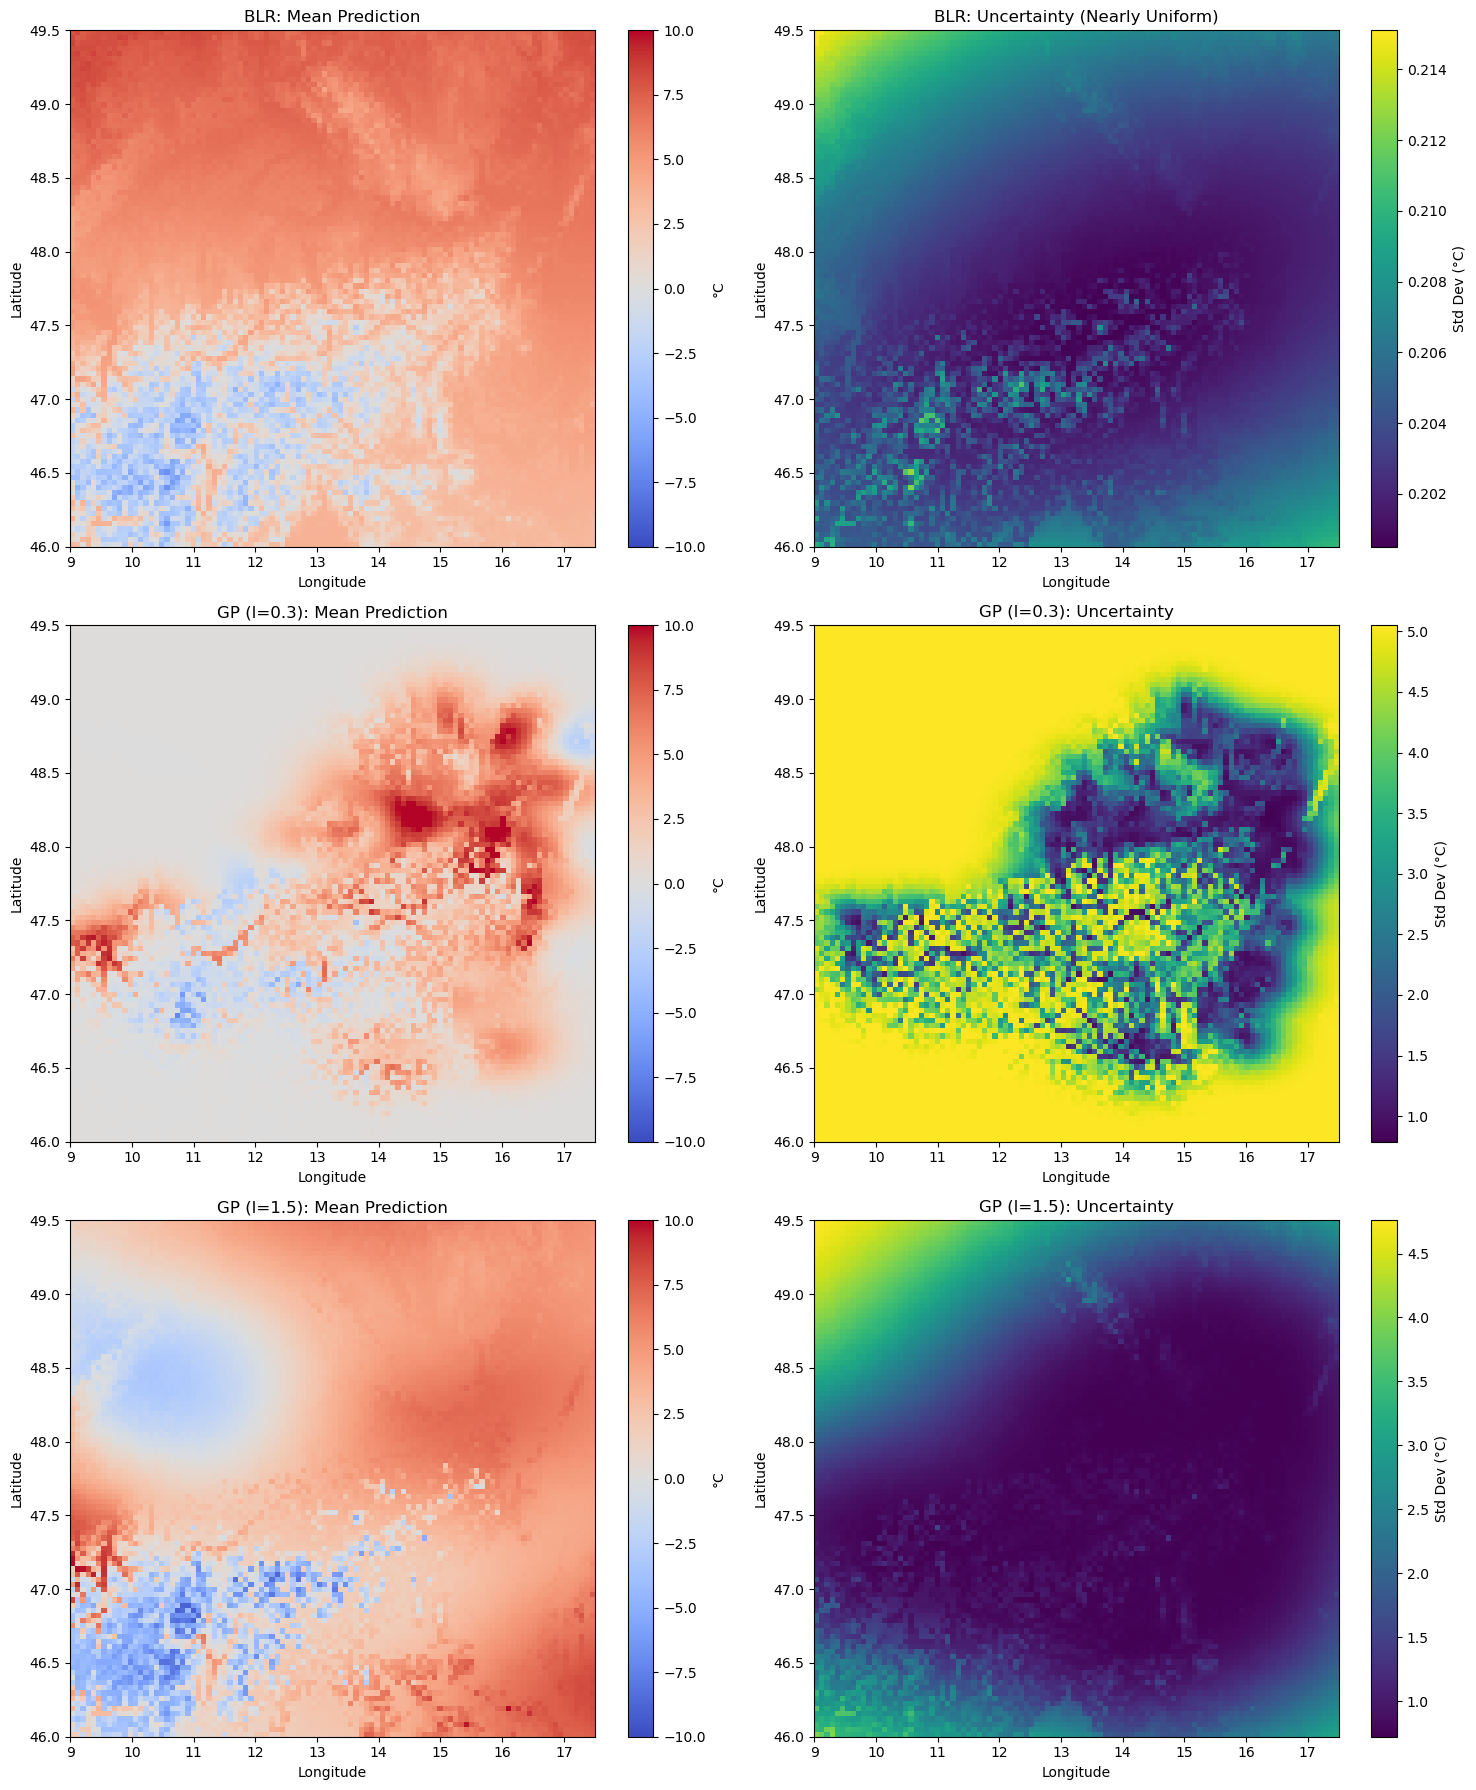


SUMMARY TABLE:
Model                Mean Temp (C)      Mean Uncertainty (C)   Uncertainty Pattern 
--------------------------------------------------------------------------------
BLR                  3.92             0.2041             Uniform
GP (l=0.3)           1.59             4.2401             Location-dependent (highly variable)
GP (l=1.5)           2.62             1.7199             Location-dependent (smooth)

Key Difference:
   BLR uncertainty range: 0.0146°C (almost flat)
   GP (l=0.3) uncertainty range: 4.2605°C (highly variable)
   GP (l=1.5) uncertainty range: 4.0357°C (moderately variable)
   


In [14]:
# GP Comparison with BLR


print("BLR vs Two GP Models")


fig, axes = plt.subplots(3, 2, figsize=(15, 18))


#  BLR
im1 = axes[0,0].imshow(predictions_map, 
                       extent=[grid_lon_flat.min(), grid_lon_flat.max(),
                              grid_lat_flat.min(), grid_lat_flat.max()],
                       origin='lower', cmap='coolwarm', aspect='auto',
                       vmin=-10, vmax=10)
axes[0,0].set_title('BLR: Mean Prediction', fontsize=12)
axes[0,0].set_xlabel('Longitude')
axes[0,0].set_ylabel('Latitude')
plt.colorbar(im1, ax=axes[0,0], label='°C')

im2 = axes[0,1].imshow(np.sqrt(uncertainty_map), 
                       extent=[grid_lon_flat.min(), grid_lon_flat.max(),
                              grid_lat_flat.min(), grid_lat_flat.max()],
                       origin='lower', cmap='viridis', aspect='auto')
axes[0,1].set_title('BLR: Uncertainty (Nearly Uniform)', fontsize=12)
axes[0,1].set_xlabel('Longitude')
axes[0,1].set_ylabel('Latitude')
plt.colorbar(im2, ax=axes[0,1], label='Std Dev (°C)')

#  GP Model 1 (Small length scale)
im3 = axes[1,0].imshow(gp1_predictions_map, 
                       extent=[grid_lon_flat.min(), grid_lon_flat.max(),
                              grid_lat_flat.min(), grid_lat_flat.max()],
                       origin='lower', cmap='coolwarm', aspect='auto',
                       vmin=-10, vmax=10)
axes[1,0].set_title(f'GP (l={length_scale_1}): Mean Prediction', fontsize=12)
axes[1,0].set_xlabel('Longitude')
axes[1,0].set_ylabel('Latitude')
plt.colorbar(im3, ax=axes[1,0], label='°C')

im4 = axes[1,1].imshow(np.sqrt(gp1_uncertainty_map), 
                       extent=[grid_lon_flat.min(), grid_lon_flat.max(),
                              grid_lat_flat.min(), grid_lat_flat.max()],
                       origin='lower', cmap='viridis', aspect='auto')
axes[1,1].set_title(f'GP (l={length_scale_1}): Uncertainty', fontsize=12)
axes[1,1].set_xlabel('Longitude')
axes[1,1].set_ylabel('Latitude')
plt.colorbar(im4, ax=axes[1,1], label='Std Dev (°C)')

# GP Model 2 (Large length scale)

im5 = axes[2,0].imshow(gp2_predictions_map, 
                       extent=[grid_lon_flat.min(), grid_lon_flat.max(),
                              grid_lat_flat.min(), grid_lat_flat.max()],
                       origin='lower', cmap='coolwarm', aspect='auto',
                       vmin=-10, vmax=10)
axes[2,0].set_title(f'GP (l={length_scale_2}): Mean Prediction', fontsize=12)
axes[2,0].set_xlabel('Longitude')
axes[2,0].set_ylabel('Latitude')
plt.colorbar(im5, ax=axes[2,0], label='°C')

im6 = axes[2,1].imshow(np.sqrt(gp2_uncertainty_map), 
                       extent=[grid_lon_flat.min(), grid_lon_flat.max(),
                              grid_lat_flat.min(), grid_lat_flat.max()],
                       origin='lower', cmap='viridis', aspect='auto')
axes[2,1].set_title(f'GP (l={length_scale_2}): Uncertainty', fontsize=12)
axes[2,1].set_xlabel('Longitude')
axes[2,1].set_ylabel('Latitude')
plt.colorbar(im6, ax=axes[2,1], label='Std Dev (°C)')

plt.tight_layout()
plt.show()

print("\nSUMMARY TABLE:")
print(f"{'Model':<20} {'Mean Temp (C)':<18} {'Mean Uncertainty (C)':<22} {'Uncertainty Pattern':<20}")
print("-"*80)
print(f"{'BLR':<20} {predictions.mean():.2f}{'':<12} {np.sqrt(uncertainties.mean()):.4f}{'':<12} Uniform")
print(f"{'GP (l=0.3)':<20} {gp1_mean.mean():.2f}{'':<12} {np.sqrt(gp1_var.mean()):.4f}{'':<12} Location-dependent (highly variable)")
print(f"{'GP (l=1.5)':<20} {gp2_mean.mean():.2f}{'':<12} {np.sqrt(gp2_var.mean()):.4f}{'':<12} Location-dependent (smooth)")


print(f"""
Key Difference:
   BLR uncertainty range: {np.sqrt(uncertainties.max()) - np.sqrt(uncertainties.min()):.4f}°C (almost flat)
   GP (l=0.3) uncertainty range: {np.sqrt(gp1_var.max()) - np.sqrt(gp1_var.min()):.4f}°C (highly variable)
   GP (l=1.5) uncertainty range: {np.sqrt(gp2_var.max()) - np.sqrt(gp2_var.min()):.4f}°C (moderately variable)
   """)

Comparison with BLR 

Mean Prediction

BLR produces very smooth and nearly uniform temperature maps, but fails to capture local spatial variations (e.g., mountainous regions).
GP (l = 0.3) captures fine local details, but results are noisy and fragmented due to high sensitivity to nearby points.
GP ( l = 1.5) provides the best balance, producing smooth yet structured temperature patterns that reflect realistic spatial trends across Austria.

Uncertainty

BLR shows nearly constant and very low uncertainty (~0.20°C), indicating overconfidence and inability to reflect data sparsity.
GP (l = 0.3) shows very high uncertainty (~4.24°C), especially far from stations.
GP (l = 1.5) shows moderate, location-dependent uncertainty (~1.72°C), with:
low uncertainty near stations
higher uncertainty in sparse regions (e.g., mountains)

Task 2.3: Ice Warning System

 Using test[0,:] as evidence
   Evidence stations: 199
   Temperature range: -14.30°C to 8.80°C
   Timestamp: b'2026-03-23T00:10+00:00'

 Two bandwidths 
   Bandwidth 1 (small, local): l = 0.3
   Bandwidth 2 (large, smooth): l = 1.5

 Training GP models with both bandwidths
   Kernel matrix shape: (199, 199)
   Condition number: 5.24e+02
   GP Model 1 (l=0.3) trained
   Kernel matrix shape: (199, 199)
   Condition number: 4.43e+03
   GP Model 2 (l=1.5) trained  

 Predicting on grid points
   Model 1 (l=0.3): Temp -11.12°C to 9.37°C
   Model 2 (l=1.5): Temp -13.58°C to 9.62°C

 Calculating P(T <= 0 °C)
   Model 1: Prob range 0.0000 to 1.0000
   Model 2: Prob range 0.0000 to 1.0000

 Issuing ice warnings using Model 2 (l=1.5)
   Warning threshold: 80.0%
   Model 1 (l=0.3): 361 warning points (3.6%)
   Model 2 (l=1.5): 2156 warning points (21.6%)
   High Risk: 2156 points (21.6%)
   Medium Risk: 792 points (7.9%)
   Low Risk: 7052 points (70.5%)

 Creating v

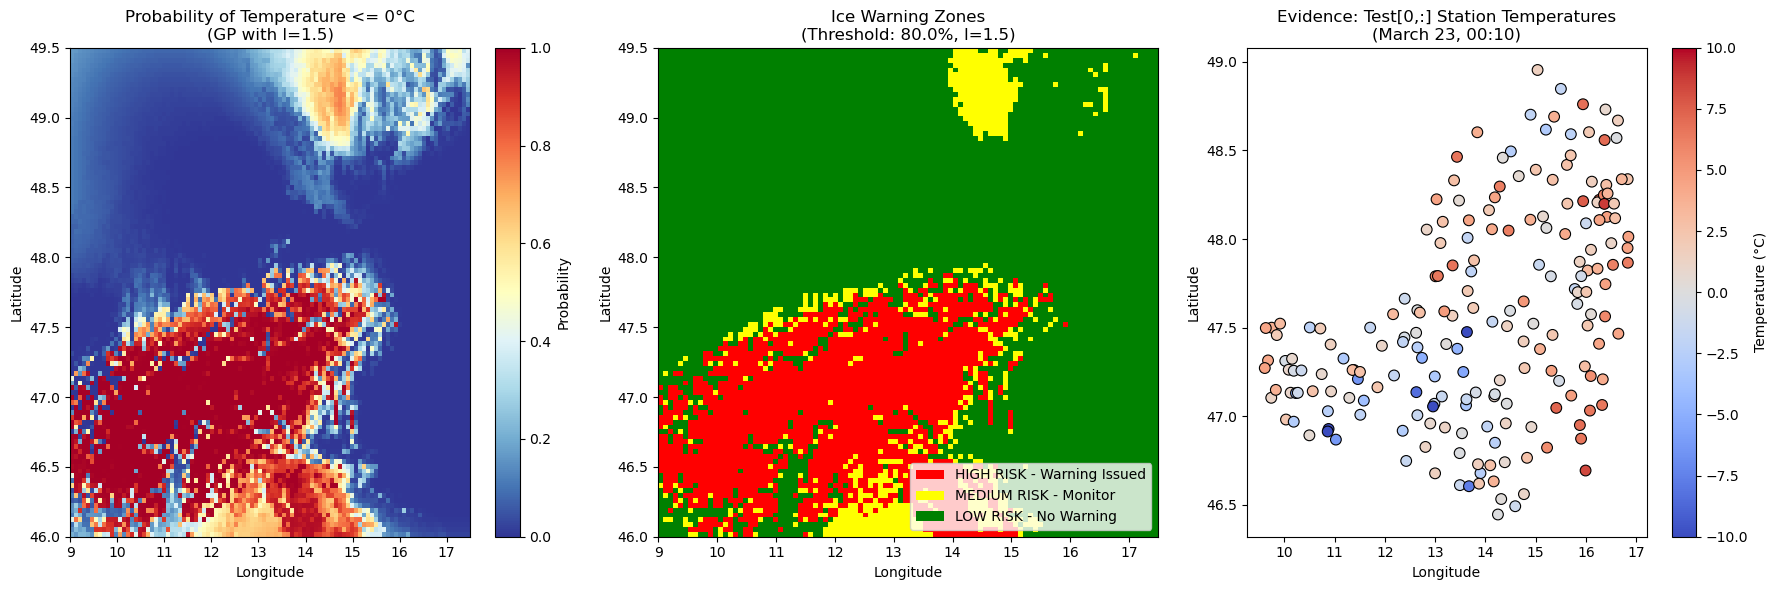

Spatial distribution analysis

Warning Zone Statistics:
   Warning points: 2156 out of 10000
   Percentage of Austria: 21.6%
   Average longitude: 12.140°
   Average latitude: 46.886°
   Average altitude: 1762m

Altitude Comparison:
   Warning zones altitude: 1762m
   Safe zones altitude: 515m
   Warning zones are 1247m higher


In [15]:
# Task 2.3: Ice Warning System

from scipy import special
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


print("Task 2.3: Ice Warning System")

# Prepare evidence from test data


print("\n Using test[0,:] as evidence")

X_evidence_raw = np.column_stack([station_lon, station_lat, station_altitude])
X_evidence = scaler_X.transform(X_evidence_raw)
y_evidence = test[0, :]

print(f"   Evidence stations: {len(y_evidence)}")
print(f"   Temperature range: {y_evidence.min():.2f}°C to {y_evidence.max():.2f}°C")
print(f"   Timestamp: {test_timesteps[0]}")

#  Define two bandwidths

length_scale_1 = 0.3   # Small bandwidth 
length_scale_2 = 1.5   # Large bandwidth

print(f"\n Two bandwidths ")
print(f"   Bandwidth 1 (small, local): l = {length_scale_1}")
print(f"   Bandwidth 2 (large, smooth): l = {length_scale_2}")


# Training both GP models


print("\n Training GP models with both bandwidths")

# GP Model 1 (Small bandwidth)
kernel_ice_1 = RBFKernel(length_scale=length_scale_1, sigma_f=5.0)
gp_ice_1 = GaussianProcess(kernel_ice_1, noise_variance=0.5)
gp_ice_1.fit(X_evidence, y_evidence)
print(f"   GP Model 1 (l={length_scale_1}) trained")

# GP Model 2 (Large bandwidth) 
kernel_ice_2 = RBFKernel(length_scale=length_scale_2, sigma_f=5.0)
gp_ice_2 = GaussianProcess(kernel_ice_2, noise_variance=0.5)
gp_ice_2.fit(X_evidence, y_evidence)
print(f"   GP Model 2 (l={length_scale_2}) trained  ")


# Predict on grid points with both models


print("\n Predicting on grid points")

# Model 1 predictions
grid_mean_1, grid_var_1 = gp_ice_1.predict(X_grid)
print(f"   Model 1 (l={length_scale_1}): Temp {grid_mean_1.min():.2f}°C to {grid_mean_1.max():.2f}°C")

# Model 2 predictions 
grid_mean_2, grid_var_2 = gp_ice_2.predict(X_grid)
print(f"   Model 2 (l={length_scale_2}): Temp {grid_mean_2.min():.2f}°C to {grid_mean_2.max():.2f}°C")


# Calculate freezing probability for both models


print("\n Calculating P(T <= 0 °C)")

def calculate_freezing_probability(mean_temp, var_temp):
    std_temp = np.sqrt(np.maximum(var_temp, 1e-10))
    z_score = (0 - mean_temp) / std_temp
    return 0.5 * (1 + special.erf(z_score / np.sqrt(2)))

freezing_prob_1 = calculate_freezing_probability(grid_mean_1, grid_var_1)
freezing_prob_2 = calculate_freezing_probability(grid_mean_2, grid_var_2)

print(f"   Model 1: Prob range {freezing_prob_1.min():.4f} to {freezing_prob_1.max():.4f}")
print(f"   Model 2: Prob range {freezing_prob_2.min():.4f} to {freezing_prob_2.max():.4f}")

# Issue warnings using model 2 (large bandwidth)

print("\n Issuing ice warnings using Model 2 (l=1.5)")

WARNING_THRESHOLD = 0.8

# Using Model 2 for final warnings
warnings = freezing_prob_2 >= WARNING_THRESHOLD
warnings_1 = freezing_prob_1 >= WARNING_THRESHOLD  # For comparison only

high_risk = warnings
medium_risk = (freezing_prob_2 >= 0.5) & (~warnings)
low_risk = freezing_prob_2 < 0.5

print(f"   Warning threshold: {WARNING_THRESHOLD*100}%")
print(f"   Model 1 (l=0.3): {warnings_1.sum()} warning points ({warnings_1.mean()*100:.1f}%)")
print(f"   Model 2 (l=1.5): {warnings.sum()} warning points ({warnings.mean()*100:.1f}%)")
print(f"   High Risk: {high_risk.sum()} points ({high_risk.mean()*100:.1f}%)")
print(f"   Medium Risk: {medium_risk.sum()} points ({medium_risk.mean()*100:.1f}%)")
print(f"   Low Risk: {low_risk.sum()} points ({low_risk.mean()*100:.1f}%)")


#  Reshape for visualization


freezing_prob_map = freezing_prob_2.reshape(100, 100)
warnings_map = warnings.reshape(100, 100)


# Visualize warning zones


print("\n Creating visualizations")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Freezing probability map (using Model 2)
im1 = axes[0].imshow(freezing_prob_map, 
                     extent=[grid_lon_flat.min(), grid_lon_flat.max(),
                            grid_lat_flat.min(), grid_lat_flat.max()],
                     origin='lower', cmap='RdYlBu_r', aspect='auto',
                     vmin=0, vmax=1)
axes[0].set_title(f'Probability of Temperature <= 0°C\n(GP with l={length_scale_2})', fontsize=12)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
plt.colorbar(im1, ax=axes[0], label='Probability')

# Plot 2: Warning zones (using Model 2)
risk_colors = np.zeros_like(freezing_prob_map)
risk_colors[warnings_map] = 2
risk_colors[medium_risk.reshape(100, 100)] = 1
risk_colors[low_risk.reshape(100, 100)] = 0

risk_cmap = ListedColormap(['green', 'yellow', 'red'])

im2 = axes[1].imshow(risk_colors, 
                     extent=[grid_lon_flat.min(), grid_lon_flat.max(),
                            grid_lat_flat.min(), grid_lat_flat.max()],
                     origin='lower', cmap=risk_cmap, aspect='auto',
                     vmin=0, vmax=2)
axes[1].set_title(f'Ice Warning Zones\n(Threshold: {WARNING_THRESHOLD*100}%, l={length_scale_2})', fontsize=12)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

legend_elements = [
    Patch(facecolor='red', label='HIGH RISK - Warning Issued'),
    Patch(facecolor='yellow', label='MEDIUM RISK - Monitor'),
    Patch(facecolor='green', label='LOW RISK - No Warning')
]
axes[1].legend(handles=legend_elements, loc='lower right')

# Plot 3: Evidence stations (test[0,:] data)
scatter = axes[2].scatter(station_lon, station_lat, 
                         c=y_evidence, cmap='coolwarm', 
                         s=60, edgecolors='black', linewidth=0.8,
                         vmin=-10, vmax=10)
axes[2].set_title('Evidence: Test[0,:] Station Temperatures\n(March 23, 00:10)', fontsize=12)
axes[2].set_xlabel('Longitude')
axes[2].set_ylabel('Latitude')
plt.colorbar(scatter, ax=axes[2], label='Temperature (°C)')

plt.tight_layout()
plt.show()


# Spatial distribution analysis

print("Spatial distribution analysis")

warning_lons = grid_lon_flat[warnings]
warning_lats = grid_lat_flat[warnings]
warning_alts = grid_alt_flat[warnings]

print(f"\nWarning Zone Statistics:")
print(f"   Warning points: {len(warning_lons)} out of {len(grid_lon_flat)}")
print(f"   Percentage of Austria: {len(warning_lons)/len(grid_lon_flat)*100:.1f}%")
print(f"   Average longitude: {warning_lons.mean():.3f}°")
print(f"   Average latitude: {warning_lats.mean():.3f}°")
print(f"   Average altitude: {warning_alts.mean():.0f}m")

print(f"\nAltitude Comparison:")
print(f"   Warning zones altitude: {warning_alts.mean():.0f}m")
print(f"   Safe zones altitude: {grid_alt_flat[~warnings].mean():.0f}m")
print(f"   Warning zones are {warning_alts.mean() - grid_alt_flat[~warnings].mean():.0f}m higher")



 Active Learning for Weather Forecasting

 Filtering grid points to actual Austria border
   Loaded Austria border from geojson
   Total grid points: 10000
   Points inside Austria (actual border): 3310
   Points filtered out: 6690
   Budget: Build 100 new weather stations

 Standardizing features
   Features standardized (mean=0, std=1)

 Running Active Learning with Two Bandwidths
Bandwidth 1: l = 0.3 (small, local)

   Greedy selection in progress (l=0.3):
      First selection: random (all points have equal prior variance)
      Selected 20/100 locations
      Selected 40/100 locations
      Selected 60/100 locations
      Selected 80/100 locations
      Selected 100/100 locations
 
 Bandwidth 2: l = 1.5 (large, smooth)

   Greedy selection in progress (l=1.5):
      First selection: random (all points have equal prior variance)
      Selected 20/100 locations
      Selected 40/100 locations
      Selected 60/100 locations
      Selected 80/100 locations
      Selected 100/100 loca

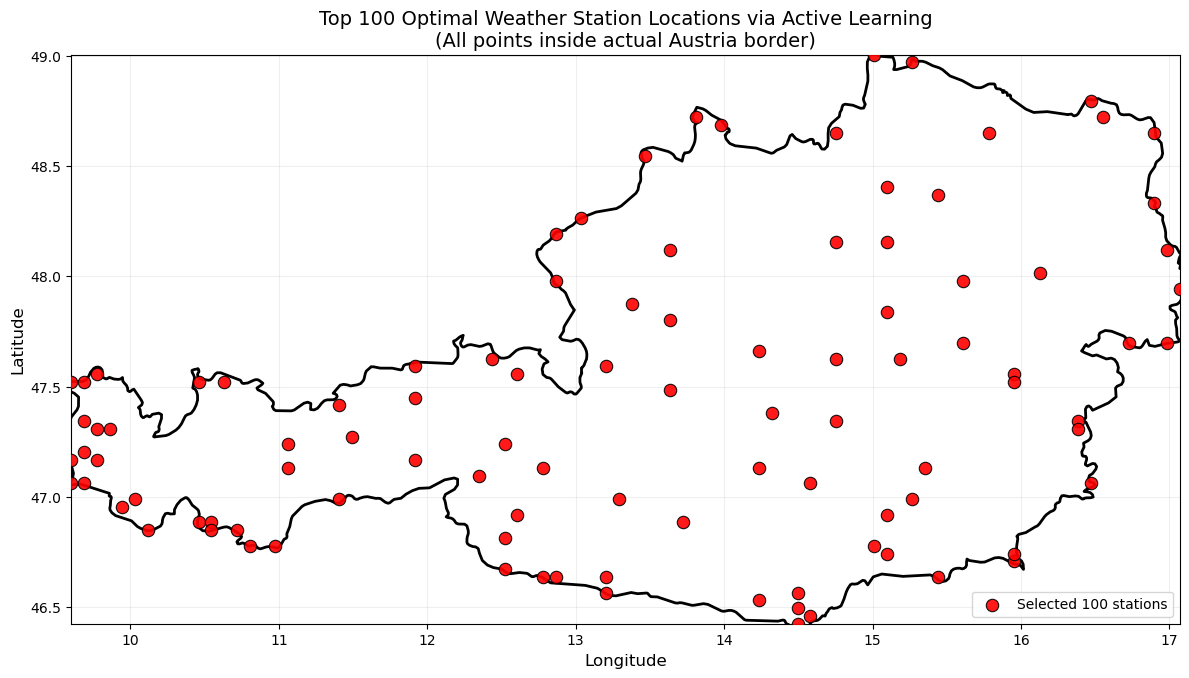

In [16]:
# Task 3.1: Implement Active Learning for Weather Forecasting


print(" Active Learning for Weather Forecasting")



#  Load Austria border and filter points


print("\n Filtering grid points to actual Austria border")

import geopandas as gpd
from shapely.geometry import Point

# Load Austria border
border = gpd.read_file('austria-detailed-boundary_854.geojson')
border.set_crs(epsg=4326, inplace=True)

print(f"   Loaded Austria border from geojson")

# Get all grid points
candidate_lon_all = grid_lon_flat
candidate_lat_all = grid_lat_flat
candidate_alt_all = grid_alt_flat

# Filter points inside Austria using actual border
points_in_austria = []
indices_in_austria = []

for i, (lon, lat) in enumerate(zip(candidate_lon_all, candidate_lat_all)):
    point = Point(lon, lat)
    if border.contains(point).any():
        points_in_austria.append((lon, lat, candidate_alt_all[i]))
        indices_in_austria.append(i)

points_in_austria = np.array(points_in_austria)

candidate_lon = points_in_austria[:, 0]
candidate_lat = points_in_austria[:, 1]
candidate_alt = points_in_austria[:, 2]
candidate_coords = np.column_stack([candidate_lon, candidate_lat, candidate_alt])

print(f"   Total grid points: {len(candidate_lon_all)}")
print(f"   Points inside Austria (actual border): {len(candidate_lon)}")
print(f"   Points filtered out: {len(candidate_lon_all) - len(candidate_lon)}")
print(f"   Budget: Build 100 new weather stations")


#  Standardize features


print("\n Standardizing features")

from sklearn.preprocessing import StandardScaler
scaler_al = StandardScaler()
candidate_coords_scaled = scaler_X.transform(candidate_coords)


print(f"   Features standardized (mean=0, std=1)")


#  Define Active Learning Class

class GreedyActiveLearner:
    def __init__(self, length_scale, sigma_f=5.0, noise_variance=0.5, random_seed=42):
        self.length_scale = length_scale
        self.sigma_f = sigma_f
        self.noise_variance = noise_variance
        self.random_seed = random_seed
        self.selected_indices = []
        self.selected_coords = []
    
    def rbf_kernel(self, X1, X2):
        from scipy.spatial.distance import cdist
        sq_dist = cdist(X1, X2, 'sqeuclidean')
        return self.sigma_f**2 * np.exp(-0.5 * sq_dist / self.length_scale**2)
    
    def select_locations(self, candidate_coords, n_select=100):
        np.random.seed(self.random_seed)
        self.selected_indices = []
        self.selected_coords = []
        
        remaining_indices = list(range(len(candidate_coords)))
        remaining_coords = candidate_coords.copy()
        
        print(f"\n   Greedy selection in progress (l={self.length_scale}):")
        
        for i in range(n_select):
            if len(self.selected_indices) == 0:
                best_local_idx = np.random.randint(len(remaining_coords))
                if i == 0:
                    print(f"      First selection: random (all points have equal prior variance)")
            else:
                X_sel = np.array(self.selected_coords)
                K_sel = self.rbf_kernel(X_sel, X_sel)
                K_sel += self.noise_variance * np.eye(len(X_sel))
                K_inv = np.linalg.inv(K_sel)
                
                variances = []
                for x in remaining_coords:
                    k_x = self.rbf_kernel(x.reshape(1, -1), X_sel).flatten()
                    k_xx = self.rbf_kernel(x.reshape(1, -1), x.reshape(1, -1))[0, 0]
                    var = k_xx - k_x @ K_inv @ k_x
                    variances.append(var)
                variances = np.array(variances)
                best_local_idx = np.argmax(variances)
            
            best_global_idx = remaining_indices[best_local_idx]
            
            self.selected_indices.append(best_global_idx)
            self.selected_coords.append(candidate_coords[best_global_idx])
            
            remaining_indices.pop(best_local_idx)
            remaining_coords = np.delete(remaining_coords, best_local_idx, axis=0)
            
            if (i + 1) % 20 == 0:
                print(f"      Selected {i+1}/{n_select} locations")
        
        return self.selected_indices


#  Run active learning with both bandwidths



print("\n Running Active Learning with Two Bandwidths")


# Bandwidth 1( l=0.3)

print("Bandwidth 1: l = 0.3 (small, local)")


learner_1 = GreedyActiveLearner(length_scale=0.3, sigma_f=5.0, noise_variance=0.5, random_seed=42)
selected_indices_1 = learner_1.select_locations(candidate_coords_scaled, n_select=100)

selected_lon_1 = candidate_lon[selected_indices_1]
selected_lat_1 = candidate_lat[selected_indices_1]
selected_alt_1 = candidate_alt[selected_indices_1]

# Bandwidth 2 (l=1.5)

print(" \n Bandwidth 2: l = 1.5 (large, smooth)")


learner_2 = GreedyActiveLearner(length_scale=1.5, sigma_f=5.0, noise_variance=0.5, random_seed=42)
selected_indices_2 = learner_2.select_locations(candidate_coords_scaled, n_select=100)

selected_lon_2 = candidate_lon[selected_indices_2]
selected_lat_2 = candidate_lat[selected_indices_2]
selected_alt_2 = candidate_alt[selected_indices_2]

#  Comparison statistics



print(" \n Comparison of Two Bandwidths")


from scipy.spatial.distance import pdist

# Statistics for Bandwidth 1
if len(selected_lon_1) > 1:
    distances_1 = pdist(np.column_stack([selected_lon_1, selected_lat_1]))
    avg_distance_1_km = np.mean(distances_1) * 111
else:
    avg_distance_1_km = 0

# Statistics for Bandwidth 2
if len(selected_lon_2) > 1:
    distances_2 = pdist(np.column_stack([selected_lon_2, selected_lat_2]))
    avg_distance_2_km = np.mean(distances_2) * 111
else:
    avg_distance_2_km = 0

overlap = len(set(selected_indices_1) & set(selected_indices_2))

print(f"\n{'Metric':<35} {'l=0.3':<18} {'l=1.5':<18}")
print("-"*70)
print(f"{'Average distance (km)':<35} {avg_distance_1_km:.0f}{'':<12} {avg_distance_2_km:.0f}")
print(f"{'Average altitude (m)':<35} {selected_alt_1.mean():.0f}{'':<12} {selected_alt_2.mean():.0f}")
print(f"{'Overlap':<35} {overlap} common points out of 100")


#  Final Visualization with Austria border


print("\n Final Top 100 Locations Map (Inside  Austria Border)")


fig, ax = plt.subplots(figsize=(12, 9))

# Plot Austria border
border.boundary.plot(ax=ax, edgecolor='black', linewidth=2, color='black')

# Plot selected locations (all inside Austria)
ax.scatter(selected_lon_2, selected_lat_2, c='red', s=80, alpha=0.9, 
           edgecolors='black', linewidth=0.8, label=f'Selected 100 stations', zorder=5)

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Top 100 Optimal Weather Station Locations via Active Learning\n(All points inside actual Austria border)', fontsize=14)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.2)
ax.set_xlim(candidate_lon.min(), candidate_lon.max())
ax.set_ylim(candidate_lat.min(), candidate_lat.max())
plt.tight_layout()
plt.show()





Interpretation
The selected stations are spread out across Austria rather than clustered. This occurs because once a location is selected, the predictive variance in its neighborhood decreases, making nearby points less informative and encouraging selection in other regions.
The final map shows the Top 100 selected locations (using l = 1.5), all of which lie within Austria. The stations are distributed across:
Western mountainous regions (higher uncertainty)
Central regions
Eastern lowlands

Impact of Active Learning improves prediction quality by reducing uncertainty across the region through strategic station placement. By selecting high-variance locations, the model gains the most useful information, leading to better generalization. This approach avoids redundant clustering and enables efficient use of a limited number of stations, while also allowing optimal placement to be determined in advance.



 Model Comparison

 Preparing test data
   Training on: b'2026-03-09T00:00+00:00' (first training timestep)
   Testing on:  b'2026-03-23T00:10+00:00' (first test timestep)
   Note: Test uses same 199 station locations, different time
   (Evaluating temporal generalization, not spatial)
   Test data: 199 stations
   Test temperature range: -14.30C to 8.80C

 Ensuring all models are trained
   BLR model exists
   Training GP Spatial...
   Kernel matrix shape: (199, 199)
   Condition number: 5.37e+03
   Training GP Full...
   Kernel matrix shape: (199, 199)
   Condition number: 4.43e+03

 Getting predictions from all models
   BLR mean range: -5.88C to 7.15C
   GP Spatial mean range: -2.13C to 7.04C
   GP Full mean range: -9.19C to 8.37C

 Training additional GP models with l=0.3
   Training GP Spatial (l=0.3)...
   Kernel matrix shape: (199, 199)
   Condition number: 6.80e+02
   Training GP Full (l=0.3)...
   Kernel matrix shape: (199, 199)
   Condition number: 5.24e+02

 Getting predic

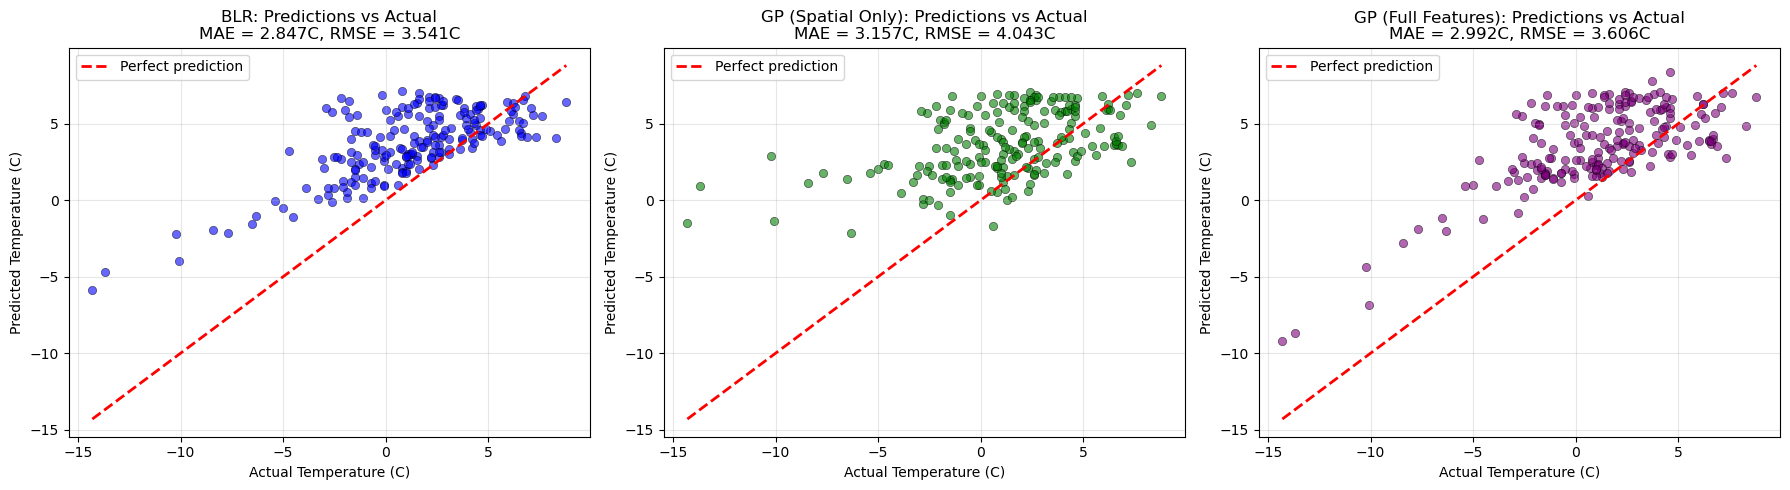

Summary for Report


MOdel Comparison Result                            


  Training/Test Split:                                                       
  ───────────────────                                                        
  Training on: b'2026-03-09T00:00+00:00'                                      
  Testing on:  b'2026-03-23T00:10+00:00'                                      
  Note: Same 199 locations, different time (temporal generalization)        

  Accuracy (lower is better):                                               
  ─────────────────────────                                                 
  BLR                    MSE = 12.538101    RMSE = 3.5409C    MAE = 2.8469C
  GP (Spatial Only)      MSE = 16.348770    RMSE = 4.0434C    MAE = 3.1574C
  GP (Full Features)     MSE = 13.000790    RMSE = 3.6057C    MAE = 2.9924C

  Best model for accuracy: BLR                                

  Uncertainity (test set):                                                    
  ─────

In [17]:
# Task 4.1: Model Comparison


print("\n Model Comparison")

# Prepare test data


print("\n Preparing test data")

print(f"   Training on: {train_timesteps[0]} (first training timestep)")
print(f"   Testing on:  {test_timesteps[0]} (first test timestep)")
print(f"   Note: Test uses same 199 station locations, different time")
print(f"   (Evaluating temporal generalization, not spatial)")

X_test_raw = np.column_stack([station_lon, station_lat, station_altitude])
X_test = scaler_X.transform(X_test_raw)
y_test_true = test[0, :]

print(f"   Test data: {len(y_test_true)} stations")
print(f"   Test temperature range: {y_test_true.min():.2f}C to {y_test_true.max():.2f}C")


#  Ensure all models exist


print("\n Ensuring all models are trained")

# Check and train BLR if needed
try:
    blr
    print("   BLR model exists")
except:
    print("   Training BLR...")
    blr = BayesianLinearRegression(alpha=1.0, beta=25.0)
    blr.fit(X_train, y_train)

# Check and train GP Spatial (only lon, lat)
try:
    gp_spatial
    print("   GP Spatial model exists")
except:
    print("   Training GP Spatial...")
    kernel_spatial = RBFKernel(length_scale=1.5, sigma_f=5.0)
    gp_spatial = GaussianProcess(kernel_spatial, noise_variance=0.5)
    gp_spatial.fit(X_train[:, :2], y_train)

# Check and train GP (lon, lat, alt)
try:
    gp
    print("   GP Full model exists")
except:
    print("   Training GP Full...")
    kernel_full = RBFKernel(length_scale=1.5, sigma_f=5.0)
    gp = GaussianProcess(kernel_full, noise_variance=0.5)
    gp.fit(X_train, y_train)


#  Get predictions from all models


print("\n Getting predictions from all models")

# BLR
blr_mean, blr_var = blr.predict(X_test)
print(f"   BLR mean range: {blr_mean.min():.2f}C to {blr_mean.max():.2f}C")

# GP Spatial
gp_spatial_mean, gp_spatial_var = gp_spatial.predict(X_test[:, :2])
print(f"   GP Spatial mean range: {gp_spatial_mean.min():.2f}C to {gp_spatial_mean.max():.2f}C")

# GP Full
gp_full_mean, gp_full_var = gp.predict(X_test)
print(f"   GP Full mean range: {gp_full_mean.min():.2f}C to {gp_full_mean.max():.2f}C")


# Calculate accuracy metrics (including RMSE)

# Train additional GP models with l=0.3


print("\n Training additional GP models with l=0.3")

# GP Spatial (only lon, lat) with l=0.3
print("   Training GP Spatial (l=0.3)...")
kernel_spatial_03 = RBFKernel(length_scale=0.3, sigma_f=5.0)
gp_spatial_03 = GaussianProcess(kernel_spatial_03, noise_variance=0.5)
gp_spatial_03.fit(X_train[:, :2], y_train)

# GP Full (lon, lat, alt) with l=0.3
print("   Training GP Full (l=0.3)...")
kernel_full_03 = RBFKernel(length_scale=0.3, sigma_f=5.0)
gp_full_03 = GaussianProcess(kernel_full_03, noise_variance=0.5)
gp_full_03.fit(X_train, y_train)


# getting predictions for all 

print("\n Getting predictions from all models")

# BLR
blr_mean, blr_var = blr.predict(X_test)
print(f"   BLR mean range: {blr_mean.min():.2f}C to {blr_mean.max():.2f}C")

# GP Spatial l=1.5
gp_spatial_mean, gp_spatial_var = gp_spatial.predict(X_test[:, :2])
print(f"   GP Spatial (l=1.5) mean range: {gp_spatial_mean.min():.2f}C to {gp_spatial_mean.max():.2f}C")

# GP Full l=1.5
gp_full_mean, gp_full_var = gp.predict(X_test)
print(f"   GP Full (l=1.5) mean range: {gp_full_mean.min():.2f}C to {gp_full_mean.max():.2f}C")

# GP Spatial l=0.3
gp_spatial_03_mean, gp_spatial_03_var = gp_spatial_03.predict(X_test[:, :2])
print(f"   GP Spatial (l=0.3) mean range: {gp_spatial_03_mean.min():.2f}C to {gp_spatial_03_mean.max():.2f}C")

# GP Full l=0.3
gp_full_03_mean, gp_full_03_var = gp_full_03.predict(X_test)
print(f"   GP Full (l=0.3) mean range: {gp_full_03_mean.min():.2f}C to {gp_full_03_mean.max():.2f}C")


# Calculate accuracy metrics


from sklearn.metrics import mean_squared_error, mean_absolute_error

results = {}


# BLR
results["BLR"] = {
    "MSE": mean_squared_error(y_test_true, blr_mean),
    "RMSE": np.sqrt(mean_squared_error(y_test_true, blr_mean)),
    "MAE": mean_absolute_error(y_test_true, blr_mean)
}

# GP Spatial l=1.5
results["GP Spatial (l=1.5)"] = {
    "MSE": mean_squared_error(y_test_true, gp_spatial_mean),
    "RMSE": np.sqrt(mean_squared_error(y_test_true, gp_spatial_mean)),
    "MAE": mean_absolute_error(y_test_true, gp_spatial_mean)
}

# GP Full l=1.5
results["GP Full (l=1.5)"] = {
    "MSE": mean_squared_error(y_test_true, gp_full_mean),
    "RMSE": np.sqrt(mean_squared_error(y_test_true, gp_full_mean)),
    "MAE": mean_absolute_error(y_test_true, gp_full_mean)
}


# GP Spatial l=0.3
results["GP Spatial (l=0.3)"] = {
    "MSE": mean_squared_error(y_test_true, gp_spatial_03_mean),
    "RMSE": np.sqrt(mean_squared_error(y_test_true, gp_spatial_03_mean)),
    "MAE": mean_absolute_error(y_test_true, gp_spatial_03_mean)
}

# GP Full l=0.3
results["GP Full (l=0.3)"] = {
    "MSE": mean_squared_error(y_test_true, gp_full_03_mean),
    "RMSE": np.sqrt(mean_squared_error(y_test_true, gp_full_03_mean)),
    "MAE": mean_absolute_error(y_test_true, gp_full_03_mean)
}

# Print results table
print(f"\n{'Model':<25} {'MSE (C²)':<15} {'RMSE (C)':<15} {'MAE (C)':<15}")
print("-"*70)
for model, metrics in results.items():
    print(f"{model:<25} {metrics['MSE']:.6f}{'':<8} {metrics['RMSE']:.4f}{'':<8} {metrics['MAE']:.4f}")


# Find best model
best_model = min(results, key=lambda x: results[x]['MAE'])
print(f"\n Best performing model (lowest MAE): {best_model} (MAE = {results[best_model]['MAE']:.4f}C)")


# Uncertainty on test set


print("Uncertainty on test set")


print(f"\n{'Model':<35} {'Avg Uncertainty (C)':<20} {'Interpretation':<20}")
print("-"*70)
print(f"{'BLR':<35} {np.sqrt(blr_var.mean()):.4f}{'':<12} {'Overconfident (uniform)'}")
print(f"{'GP (Spatial Only)':<35} {np.sqrt(gp_spatial_var.mean()):.4f}{'':<12} {'More realistic'}")
print(f"{'GP (Full Features)':<35} {np.sqrt(gp_full_var.mean()):.4f}{'':<12} {'More realistic'}")





# Does altitude reduce uncertainty in mountains?


print("\n Effect of Altitude on mountain Uncertainity")


# Get grid predictions for uncertainty analysis
gp_spatial_grid_var = gp_spatial.predict(X_grid[:, :2])[1]
gp_full_grid_var = gp.predict(X_grid)[1]

mountain_mask = grid_alt_flat > 1500
lowland_mask = grid_alt_flat < 500

spatial_mountain_unc = np.sqrt(gp_spatial_grid_var[mountain_mask]).mean()
full_mountain_unc = np.sqrt(gp_full_grid_var[mountain_mask]).mean()

spatial_lowland_unc = np.sqrt(gp_spatial_grid_var[lowland_mask]).mean()
full_lowland_unc = np.sqrt(gp_full_grid_var[lowland_mask]).mean()

print(f"\n Mountain regions (Altitude > 1500m):")
print(f"   GP (Spatial Only) uncertainty: {spatial_mountain_unc:.4f}C")
print(f"   GP (Full Features) uncertainty: {full_mountain_unc:.4f}C")

#  Proper message based on actual comparison
if full_mountain_unc < spatial_mountain_unc:
    reduction = ((spatial_mountain_unc - full_mountain_unc) / spatial_mountain_unc) * 100
    mountain_conclusion = f"YES - Altitude reduces mountain uncertainty by {reduction:.1f}%"
    print(f"\n {mountain_conclusion}")
else:
    increase = ((full_mountain_unc - spatial_mountain_unc) / spatial_mountain_unc) * 100
    mountain_conclusion = f"NO - Altitude increases predictive variance by {increase:.1f}%"
    print(f"\n {mountain_conclusion}")
   

print(f"\n Lowland regions (Altitude < 500m):")
print(f"   GP (Spatial Only) uncertainty: {spatial_lowland_unc:.4f}C")
print(f"   GP (Full Features) uncertainty: {full_lowland_unc:.4f}C")


# Computational timing


print("Computational timing (using bandwidth l=1.5)")


import time

station_counts = [50, 100, 150, 199]
blr_times = []
gp_times = []

print(f"\n{'Stations':<12} {'BLR Time (s)':<18} {'GP Time (s)':<18} {'Ratio':<10} {'Complexity':<20}")
print("-"*75)

for n in station_counts:
    X_subset = X_train[:n]
    y_subset = y_train[:n]
    
    # BLR timing
    start = time.time()
    blr_temp = BayesianLinearRegression(alpha=1.0, beta=25.0)
    blr_temp.fit(X_subset, y_subset)
    blr_time = time.time() - start
    blr_times.append(blr_time)
    
    # GP timing using l=1.5
    start = time.time()
    gp_temp = GaussianProcess(RBFKernel(length_scale=1.5, sigma_f=5.0), noise_variance=0.5)
    gp_temp.fit(X_subset, y_subset)
    gp_time = time.time() - start
    gp_times.append(gp_time)
    
    ratio = gp_time / blr_time if blr_time > 0 else 0
    print(f"{n:<12} {blr_time:.6f}{'':<10} {gp_time:.6f}{'':<10} {ratio:.1f}x{'':<6} BLR:O(N·D²) / GP:O(N³)")

actual_ratio = gp_times[-1] / blr_times[-1]
print(f"\n For 199 stations, GP is {actual_ratio:.1f}x slower than BLR")


# Visualization


print("Visualization: Predictions vs Ground Truth")
blr_mse = results["BLR"]["MSE"]
blr_rmse = results["BLR"]["RMSE"]
blr_mae = results["BLR"]["MAE"]

gp_spatial_mse = results["GP Spatial (l=1.5)"]["MSE"]
gp_spatial_rmse = results["GP Spatial (l=1.5)"]["RMSE"]
gp_spatial_mae = results["GP Spatial (l=1.5)"]["MAE"]

gp_full_mse = results["GP Full (l=1.5)"]["MSE"]
gp_full_rmse = results["GP Full (l=1.5)"]["RMSE"]
gp_full_mae = results["GP Full (l=1.5)"]["MAE"]

best_model = min(results, key=lambda x: results[x]["MAE"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: BLR
axes[0].scatter(y_test_true, blr_mean, alpha=0.6, c='blue', edgecolors='black', linewidth=0.5)
axes[0].plot([y_test_true.min(), y_test_true.max()], 
             [y_test_true.min(), y_test_true.max()], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Temperature (C)')
axes[0].set_ylabel('Predicted Temperature (C)')
axes[0].set_title(f'BLR: Predictions vs Actual\nMAE = {blr_mae:.3f}C, RMSE = {blr_rmse:.3f}C')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: GP Spatial
axes[1].scatter(y_test_true, gp_spatial_mean, alpha=0.6, c='green', edgecolors='black', linewidth=0.5)
axes[1].plot([y_test_true.min(), y_test_true.max()], 
             [y_test_true.min(), y_test_true.max()], 'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Actual Temperature (C)')
axes[1].set_ylabel('Predicted Temperature (C)')
axes[1].set_title(f'GP (Spatial Only): Predictions vs Actual\nMAE = {gp_spatial_mae:.3f}C, RMSE = {gp_spatial_rmse:.3f}C')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Plot 3: GP Full
axes[2].scatter(y_test_true, gp_full_mean, alpha=0.6, c='purple', edgecolors='black', linewidth=0.5)
axes[2].plot([y_test_true.min(), y_test_true.max()], 
             [y_test_true.min(), y_test_true.max()], 'r--', linewidth=2, label='Perfect prediction')
axes[2].set_xlabel('Actual Temperature (C)')
axes[2].set_ylabel('Predicted Temperature (C)')
axes[2].set_title(f'GP (Full Features): Predictions vs Actual\nMAE = {gp_full_mae:.3f}C, RMSE = {gp_full_rmse:.3f}C')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()


# Summary for Report



print("Summary for Report")


# FIXED: Proper mountain effect statement for summary
if full_mountain_unc < spatial_mountain_unc:
    mountain_effect = f"REDUCES by {((spatial_mountain_unc - full_mountain_unc) / spatial_mountain_unc * 100):.1f}%"
else:
    mountain_effect = f"INCREASES by {((full_mountain_unc - spatial_mountain_unc) / spatial_mountain_unc * 100):.1f}%"

print(f"""

MOdel Comparison Result                            

                                                                            
  Training/Test Split:                                                       
  ───────────────────                                                        
  Training on: {train_timesteps[0]}                                      
  Testing on:  {test_timesteps[0]}                                      
  Note: Same 199 locations, different time (temporal generalization)        
                                                                             
  Accuracy (lower is better):                                               
  ─────────────────────────                                                 
  BLR                    MSE = {blr_mse:.6f}    RMSE = {blr_rmse:.4f}C    MAE = {blr_mae:.4f}C
  GP (Spatial Only)      MSE = {gp_spatial_mse:.6f}    RMSE = {gp_spatial_rmse:.4f}C    MAE = {gp_spatial_mae:.4f}C
  GP (Full Features)     MSE = {gp_full_mse:.6f}    RMSE = {gp_full_rmse:.4f}C    MAE = {gp_full_mae:.4f}C
                                                                             
  Best model for accuracy: {best_model}                                
                                                                             
  Uncertainity (test set):                                                    
  ────────────────────────                                                  
  BLR avg uncertainty:        {np.sqrt(blr_var.mean()):.4f}C (overconfident)
  GP Spatial avg uncertainty: {np.sqrt(gp_spatial_var.mean()):.4f}C
  GP Full avg uncertainty:    {np.sqrt(gp_full_var.mean()):.4f}C
                                                                             
  Mountain Uncertainity  (Altitude > 1500m):                                   
  ─────────────────────────────────────────                                  
  GP Spatial:  {spatial_mountain_unc:.4f}C
  GP Full:     {full_mountain_unc:.4f}C
  Altitude {mountain_effect} mountain uncertainty
                                                                             
  Computational Scaling (199 stations):                                      
  ───────────────────────────────────────                                   
  BLR: {blr_times[-1]:.6f} seconds (O(N·D²) - linear)                            
  GP:  {gp_times[-1]:.6f} seconds (O(N³) - cubic)                                 
  GP is {actual_ratio:.1f}x slower                                               
                                                                             

""")



The figure shows predicted versus actual temperatures for BLR, GP (Spatial Only), and GP (Full Features). The red dashed line represents perfect predictions (y = x). Points closer to this line indicate more accurate predictions. The BLR model shows the closest alignment with the diagonal, confirming its lowest prediction error on this test set. The GP Spatial model exhibits larger deviations due to the absence of altitude information, while the GP Full model improves performance but still shows slightly higher dispersion than BLR.


Does altitude reduce predictive variance in mountainous regions?

Including altitude did not reduce predictive variance in mountainous regions. Instead, it increased uncertainty by approximately 27.8%.
This is likely because adding altitude increases the dimensionality of the input space. In mountainous regions, altitude changes sharply over short distances, so the RBF kernel computes larger distances between points. This reduces similarity between points and increases posterior variance.

Computational Trade-offs
The timing experiment shows that BLR is much faster than GP.
BLR scales efficiently because it only needs to work with the feature dimension. Its training time remains very small as the number of stations increases.
GP training is more expensive because it requires inversion of an n×n kernel matrix. This leads to cubic scaling, O(n^3). In the experiment, GP became about 135 times slower than BLR when using 199 stations.
Therefore, BLR is computationally efficient and scalable, while GP provides richer uncertainty estimates but at significantly higher computational cost.





Task 4.2: Visualization and Uncertainty Analysis 

 Analyzing GP uncertainty predictions
   Uncertainty range: 0.724C to 4.759C
   Mean uncertainty: 1.459C

 Identifying High Uncertainty Regions

   High uncertainty threshold (90th percentile): 2.845C
   Low uncertainty threshold (10th percentile): 0.747C
   High uncertainty points: 1000 (10.0%)
   Low uncertainty points: 1000 (10.0%)

 Characteristics of High Uncertainty Regions

 High Uncertainty Regions:
   Average longitude: 10.33°
   Average latitude: 48.65°
   Average altitude: 582m

 Low Uncertainty Regions:
   Average longitude: 14.80°
   Average latitude: 47.80°
   Average altitude: 491m

 Correlation Analysis

   Correlation between uncertainty and altitude: -0.109
   Correlation between uncertainty and distance to nearest station (km): 0.922
   -> Higher altitude = Lower uncertainty (-0.109 correlation)
   -> Further from stations = Higher uncertainty (+0.922 correlation)

 Loading Austria border
   Using detailed Austria bo

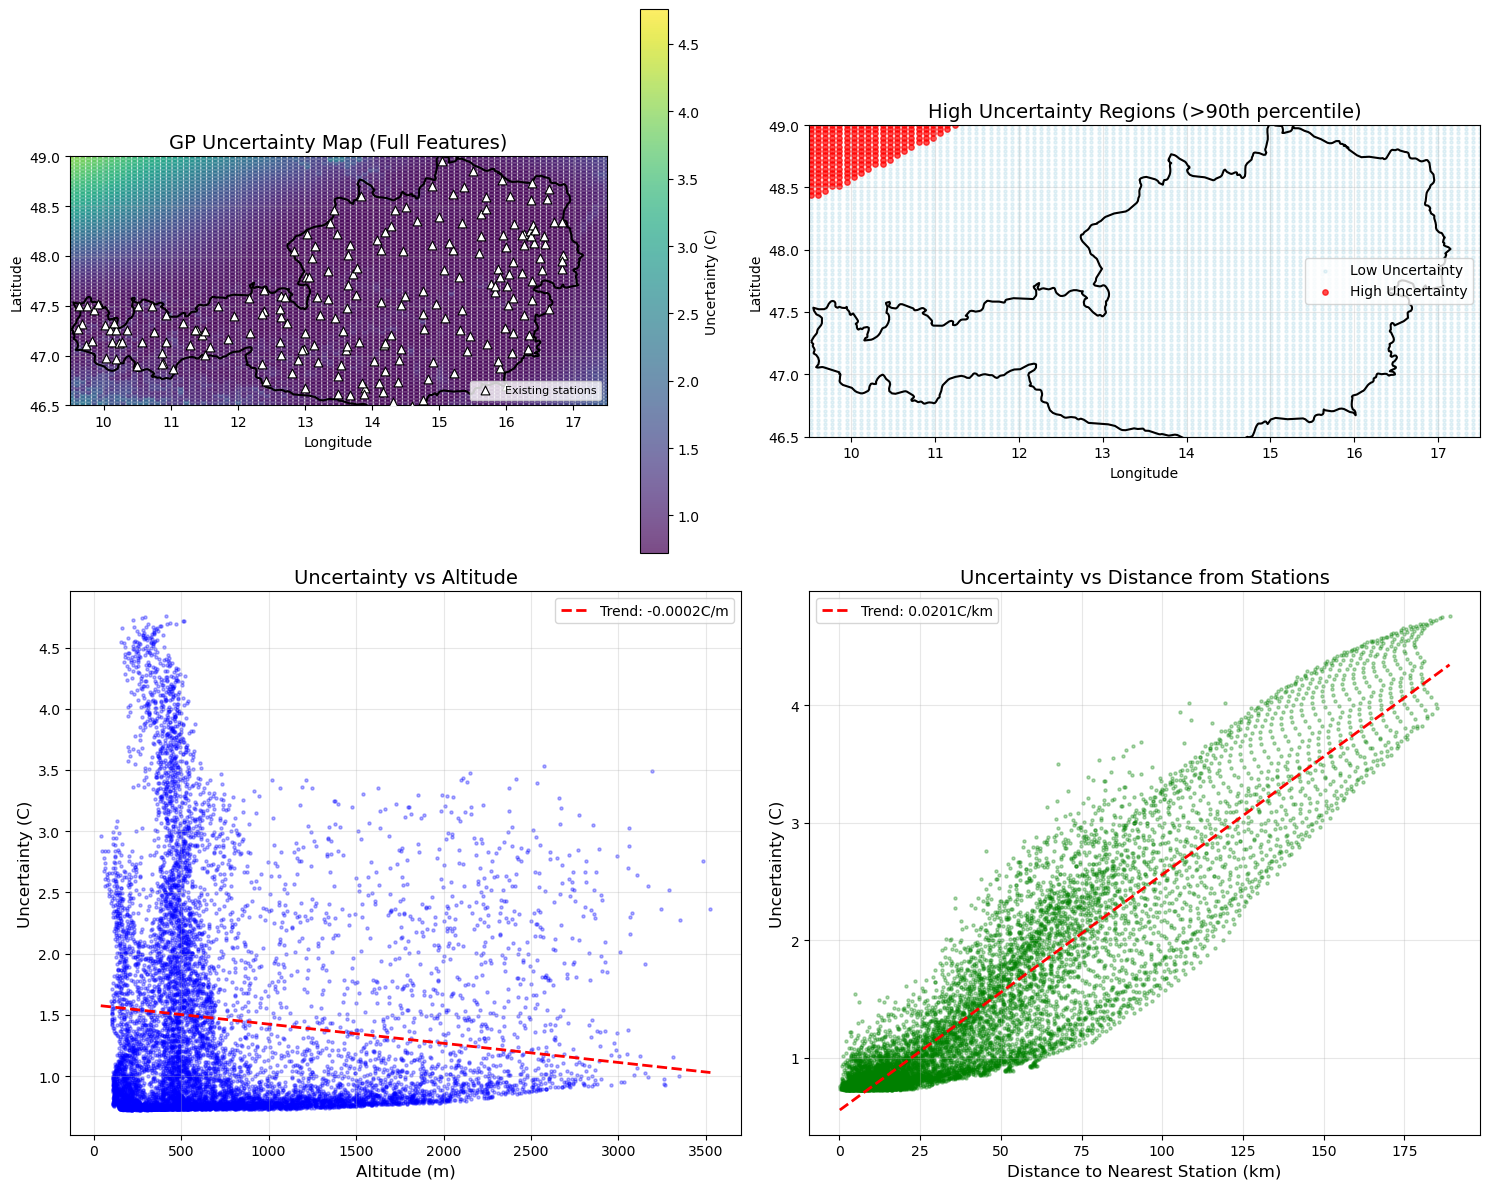


   Plot saved as 'task42_uncertainty_analysis.png'

 Where is Uncertainty Highest?

   Top 5 Highest Uncertainty Locations:
   Rank   Longitude    Latitude     Altitude     Uncertainty 
------------------------------------------------------------
   1      9.000        49.500       416          4.759       
   2      9.086        49.500       296          4.748       
   3      9.000        49.465       278          4.744       
   4      9.000        49.429       224          4.725       
   5      9.172        49.500       514          4.720       


In [18]:
# Task 4.2: Visualization and Uncertainty Analysis 


print("Task 4.2: Visualization and Uncertainty Analysis ")



# Get uncertainty from GP Full (with altitude)


print("\n Analyzing GP uncertainty predictions")


gp_full_grid_mean, gp_full_grid_var = gp.predict(X_grid)
uncertainty_gp = np.sqrt(gp_full_grid_var)

print(f"   Uncertainty range: {uncertainty_gp.min():.3f}C to {uncertainty_gp.max():.3f}C")
print(f"   Mean uncertainty: {uncertainty_gp.mean():.3f}C")


#  Identify high uncertainty regions


print("\n Identifying High Uncertainty Regions")

# Define high uncertainty (top 10%)
high_uncertainty_threshold = np.percentile(uncertainty_gp, 90)
high_uncertainty_mask = uncertainty_gp >= high_uncertainty_threshold

# Define low uncertainty (bottom 10%)
low_uncertainty_threshold = np.percentile(uncertainty_gp, 10)
low_uncertainty_mask = uncertainty_gp <= low_uncertainty_threshold

print(f"\n   High uncertainty threshold (90th percentile): {high_uncertainty_threshold:.3f}C")
print(f"   Low uncertainty threshold (10th percentile): {low_uncertainty_threshold:.3f}C")
print(f"   High uncertainty points: {high_uncertainty_mask.sum()} ({high_uncertainty_mask.mean()*100:.1f}%)")
print(f"   Low uncertainty points: {low_uncertainty_mask.sum()} ({low_uncertainty_mask.mean()*100:.1f}%)")


# Analyze characteristics of high uncertainty regions


print("\n Characteristics of High Uncertainty Regions")

# Get coordinates of high and low uncertainty points
high_unc_lon = grid_lon_flat[high_uncertainty_mask]
high_unc_lat = grid_lat_flat[high_uncertainty_mask]
high_unc_alt = grid_alt_flat[high_uncertainty_mask]

low_unc_lon = grid_lon_flat[low_uncertainty_mask]
low_unc_lat = grid_lat_flat[low_uncertainty_mask]
low_unc_alt = grid_alt_flat[low_uncertainty_mask]

print(f"\n High Uncertainty Regions:")
print(f"   Average longitude: {high_unc_lon.mean():.2f}°")
print(f"   Average latitude: {high_unc_lat.mean():.2f}°")
print(f"   Average altitude: {high_unc_alt.mean():.0f}m")

print(f"\n Low Uncertainty Regions:")
print(f"   Average longitude: {low_unc_lon.mean():.2f}°")
print(f"   Average latitude: {low_unc_lat.mean():.2f}°")
print(f"   Average altitude: {low_unc_alt.mean():.0f}m")


# Correlation analysis


print("\n Correlation Analysis")

# Distance from nearest station analysis (in km)
from scipy.spatial import cKDTree

station_coords = np.column_stack([station_lon, station_lat])
tree = cKDTree(station_coords)
distances_deg, _ = tree.query(np.column_stack([grid_lon_flat, grid_lat_flat]))
distances_km = distances_deg * 90  # Convert to km (1 degree ~ 90 km in Austria)

# Correlation with altitude
alt_corr = np.corrcoef(grid_alt_flat, uncertainty_gp)[0, 1]
print(f"\n   Correlation between uncertainty and altitude: {alt_corr:.3f}")

# Correlation with distance (km)
dist_corr = np.corrcoef(distances_km, uncertainty_gp)[0, 1]
print(f"   Correlation between uncertainty and distance to nearest station (km): {dist_corr:.3f}")

# Interpretation
if alt_corr > 0:
    print(f"   -> Higher altitude = Higher uncertainty (+{alt_corr:.3f} correlation)")
else:
    print(f"   -> Higher altitude = Lower uncertainty ({alt_corr:.3f} correlation)")
    

if dist_corr > 0:
    print(f"   -> Further from stations = Higher uncertainty (+{dist_corr:.3f} correlation)")
   


#  Load Austria border for visualization


print("\n Loading Austria border")

try:
    import geopandas as gpd
    border = gpd.read_file('austria-detailed-boundary_854.geojson')
    border.set_crs(epsg=4326, inplace=True)
    use_border = True
    print("   Using detailed Austria border from geojson")
except:
    from matplotlib.patches import Polygon
    use_border = False
    print("   Geojson not found, using simplified border polygon")


# Visualization with Austria border


print("\n Creating visualizations")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Uncertainty map of Austria (with border and stations)
if use_border:
    border.boundary.plot(ax=axes[0,0], edgecolor='black', linewidth=1.5, color=None)
scatter1 = axes[0,0].scatter(grid_lon_flat, grid_lat_flat, 
                              c=uncertainty_gp, cmap='viridis', s=10, alpha=0.7,
                              vmin=uncertainty_gp.min(), vmax=uncertainty_gp.max())
# Add station locations as white triangles
axes[0,0].scatter(station_lon, station_lat, c='white', s=40, marker='^',
                  edgecolors='black', linewidth=0.8, label='Existing stations', zorder=5)
axes[0,0].set_title('GP Uncertainty Map (Full Features)', fontsize=14)
axes[0,0].set_xlabel('Longitude')
axes[0,0].set_ylabel('Latitude')
axes[0,0].legend(loc='lower right', fontsize=8)
plt.colorbar(scatter1, ax=axes[0,0], label='Uncertainty (C)')
axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_xlim(9.5, 17.5)
axes[0,0].set_ylim(46.5, 49.0)

# Plot 2: High uncertainty regions highlighted (with border)
if use_border:
    border.boundary.plot(ax=axes[0,1], edgecolor='black', linewidth=1.5, color=None)
axes[0,1].scatter(grid_lon_flat[~high_uncertainty_mask], 
                  grid_lat_flat[~high_uncertainty_mask], 
                  c='lightblue', s=5, alpha=0.3, label='Low Uncertainty')
axes[0,1].scatter(high_unc_lon, high_unc_lat, 
                  c='red', s=15, alpha=0.7, label='High Uncertainty')
axes[0,1].set_title('High Uncertainty Regions (>90th percentile)', fontsize=14)
axes[0,1].set_xlabel('Longitude')
axes[0,1].set_ylabel('Latitude')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)
axes[0,1].set_xlim(9.5, 17.5)
axes[0,1].set_ylim(46.5, 49.0)

# Plot 3: Uncertainty vs Altitude
axes[1,0].scatter(grid_alt_flat, uncertainty_gp, c='blue', alpha=0.3, s=5)
axes[1,0].set_xlabel('Altitude (m)', fontsize=12)
axes[1,0].set_ylabel('Uncertainty (C)', fontsize=12)
axes[1,0].set_title('Uncertainty vs Altitude', fontsize=14)
axes[1,0].grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(grid_alt_flat, uncertainty_gp, 1)
p = np.poly1d(z)
axes[1,0].plot(np.sort(grid_alt_flat), p(np.sort(grid_alt_flat)), 
               'r--', linewidth=2, label=f'Trend: {z[0]:.4f}C/m')
axes[1,0].legend()

# Plot 4: Uncertainty vs Distance to nearest station (in km)
axes[1,1].scatter(distances_km, uncertainty_gp, c='green', alpha=0.3, s=5)
axes[1,1].set_xlabel('Distance to Nearest Station (km)', fontsize=12)
axes[1,1].set_ylabel('Uncertainty (C)', fontsize=12)
axes[1,1].set_title('Uncertainty vs Distance from Stations', fontsize=14)
axes[1,1].grid(True, alpha=0.3)

# Add trend line
z_dist = np.polyfit(distances_km, uncertainty_gp, 1)
p_dist = np.poly1d(z_dist)
axes[1,1].plot(np.sort(distances_km), p_dist(np.sort(distances_km)), 
               'r--', linewidth=2, label=f'Trend: {z_dist[0]:.4f}C/km')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('task42_uncertainty_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n   Plot saved as 'task42_uncertainty_analysis.png'")


# Where is uncertainty highest?


print("\n Where is Uncertainty Highest?")

top5_indices = np.argsort(uncertainty_gp)[-5:][::-1]

print(f"\n   Top 5 Highest Uncertainty Locations:")
print(f"   {'Rank':<6} {'Longitude':<12} {'Latitude':<12} {'Altitude':<12} {'Uncertainty':<12}")
print("-"*60)
for i, idx in enumerate(top5_indices[:5], 1):
    print(f"   {i:<6} {grid_lon_flat[idx]:<12.3f} {grid_lat_flat[idx]:<12.3f} {grid_alt_flat[idx]:<12.0f} {uncertainty_gp[idx]:<12.3f}")







Analysis of High Uncertainty Regions

The analysis shows that high uncertainty is primarily caused by sparse station coverage rather than altitude. Regions with the highest uncertainty are located in western Austria, where weather stations are more widely spaced.

A strong positive correlation (0.92) between uncertainty and distance to the nearest station confirms that locations far from existing stations have the highest uncertainty. In contrast, altitude has only a weak negative correlation (-0.11), indicating that elevation is not a significant driver.

Additionally, complex terrain (e.g., mountains and valleys) contributes to uncertainty, as rapid local variations are harder for the model to capture with limited data.